# Portugal salary distribution: grouped public-data fits for monthly earnings

This notebook extracts the public salary-distribution tables from the official **GEP/MTSSS Quadros de Pessoal** chronological Excel workbooks and tests how well several positive-support distributions approximate the published distribution of monthly earnings.

The key constraint is that the public workbooks expose **grouped tables**, not worker-level microdata. That means the notebook fits distributions by **grouped likelihood** on published salary brackets and then validates those fits against the published **median** and **mean earnings by decile**.

## What this notebook is trying to answer

There are two separate questions:

1. Is the public salary distribution consistent with a **Gamma** approximation?
2. If Gamma is not best, which alternatives fit the grouped data better?

To avoid overclaiming, the notebook compares **Gamma**, **Lognormal**, **Weibull**, and **Generalized Gamma**. It also computes a simple **Pareto tail diagnostic** for the top salary brackets, because the top tail is often where smooth body distributions fail.

In [1]:
from __future__ import annotations

import math
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display
from scipy import stats

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from pt_salary_gamma_distribution import (
    RMMG_BY_YEAR,
    bootstrap_grouped_parameter_ranges,
    build_manual_validation_checks,
    build_salary_bin_dataset,
    build_year_totals,
    clipped_density,
    decile_validation,
    decile_validation_summary,
    deduplicate_brackets,
    deduplicate_summaries,
    download_manifest,
    fit_lognormal_pareto_splice_all_years,
    extract_all_sources,
    fit_sensitivity_scenarios,
    fit_year_models,
    gamma_parameter_trend,
    grouped_histogram_frame,
    grouped_residuals,
    model_winners,
    optional_microdata_fit,
    pareto_tail_diagnostics,
    representative_years,
    splice_top_decile_diagnostics,
    splice_top_share_comparison,
    tail_model_comparison,
    top_share_fit_comparison,
    validate_against_percentages,
)
from pt_salary_gamma_distribution.fitting import fit_row_to_object

DATA_DIR = REPO_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
FIGURES_DIR = REPO_ROOT / "reports" / "figures"
PRIVATE_DIR = DATA_DIR / "private"
MANIFEST_PATH = DATA_DIR / "source_manifest.csv"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (6.0.0.post1)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


The notebook uses a small typed package under `src/pt_salary_gamma_distribution/` so the extraction and fitting logic can be tested separately from the notebook narrative.

## Source manifest and reproducible downloads

The manifest lists the official GEP workbook URLs. Several windows overlap, which is useful because it lets us prefer the latest published version of a year when the same year appears in more than one workbook.

In [2]:
manifest = pd.read_csv(MANIFEST_PATH)
sources = download_manifest(manifest, RAW_DIR, overwrite=False)
valid_sources = sources.query("status == 'ok'").copy()

if valid_sources.empty:
    raise RuntimeError("No official sources could be downloaded. Check the manifest or network access.")

sources.to_csv(PROCESSED_DIR / "download_status.csv", index=False)
display(sources[["source_id", "start_year", "end_year", "status", "local_path", "error"]])

,source_id,start_year,end_year,status,local_path,error
0,seriesqp_1999_2009,1999,2009,ok,C:\Users\diogo\work_code\ds-projects-portfolio...,
1,seriesqp_2007_2017,2007,2017,ok,C:\Users\diogo\work_code\ds-projects-portfolio...,
2,seriesqp_2010_2020,2010,2020,ok,C:\Users\diogo\work_code\ds-projects-portfolio...,
3,seriesqp_2011_2021,2011,2021,ok,C:\Users\diogo\work_code\ds-projects-portfolio...,
4,seriesqp_2012_2022,2012,2022,ok,C:\Users\diogo\work_code\ds-projects-portfolio...,
5,seriesqp_2013_2023,2013,2023,ok,C:\Users\diogo\work_code\ds-projects-portfolio...,
6,seriesqp_2014_2024,2014,2024,ok,C:\Users\diogo\work_code\ds-projects-portfolio...,


The main check here is whether every workbook downloads and stays a real spreadsheet rather than an HTML redirect page. In this run the downloads should all be `ok`; if not, the manifest needs an official URL refresh before any statistical work is credible.

## Extract the public grouped tables

The older 1999–2009 workbook contains remuneration context but not the grouped salary-bracket and decile tables needed for grouped likelihood. In practice, the public grouped-distribution window starts in **2007**, using the `q23/q24` structure in the older workbooks and `q32/q33` in the recent ones.

In [3]:
brackets_raw, summaries_raw = extract_all_sources(valid_sources)

source_priority = manifest.set_index("source_id")["end_year"].to_dict()
salary_brackets = deduplicate_brackets(brackets_raw, source_priority)
salary_summaries = deduplicate_summaries(summaries_raw, source_priority)
salary_bins = build_salary_bin_dataset(salary_brackets)
year_totals = build_year_totals(salary_summaries)
percentage_checks = validate_against_percentages(salary_bins)

salary_brackets.to_csv(PROCESSED_DIR / "salary_brackets_raw_long.csv", index=False)
salary_summaries.to_csv(PROCESSED_DIR / "salary_summaries_raw_long.csv", index=False)
salary_bins.to_csv(PROCESSED_DIR / "salary_bins_long.csv", index=False)
year_totals.to_csv(PROCESSED_DIR / "year_totals.csv", index=False)
percentage_checks.to_csv(PROCESSED_DIR / "salary_bin_percentage_checks.csv", index=False)

coverage_summary = pd.DataFrame(
    {
        "dataset": ["salary_brackets", "salary_summaries"],
        "first_year": [int(salary_brackets["year"].min()), int(salary_summaries["year"].min())],
        "last_year": [int(salary_brackets["year"].max()), int(salary_summaries["year"].max())],
        "n_years": [salary_brackets["year"].nunique(), salary_summaries["year"].nunique()],
    }
)
display(coverage_summary)
display(salary_bins.head(12))

,dataset,first_year,last_year,n_years
0,salary_brackets,2007,2024,18
1,salary_summaries,2007,2024,18


,year,bin_label,count,pct,lower,upper,bin_type
0,2007,< RMMG,6255.0,0.290521,0.0,403.00,below_minimum_wage
1,2007,= RMMG,110024.0,5.110198,402.5,403.50,exact_minimum_wage
2,2007,">RMMG e <= 599,99 €",688488.0,31.977661,403.0,599.99,above_minimum_wage_to_threshold
3,2007,"600,00 - 749,99 €",403847.0,18.757164,600.0,749.99,closed_range
4,2007,"750,00 - 999,99 €",347693.0,16.149024,750.0,999.99,closed_range
5,2007,"1 000,00 - 1 499,99 €",298549.0,13.866471,1000.0,1499.99,closed_range
6,2007,"1 500,00 - 2 499,99 €",199371.0,9.260028,1500.0,2499.99,closed_range
7,2007,"2 500,00 - 3 749,99 €",65645.0,3.048962,2500.0,3749.99,closed_range
8,2007,"3 750,00 - 4 999,99 €",19130.0,0.888516,3750.0,4999.99,closed_range
9,2007,"5 000,00 e + euros",14026.0,0.651455,5000.0,inf,open_top


The extraction result matters more than the raw row count. What matters is that the grouped analysis is now explicitly framed as a **2007–2024** public-data exercise, not a 1999–2024 claim. That removes the false precision that came from assuming those earlier years had the same grouped tables.

## Bracket definitions by year

Before comparing distributions across time, it is useful to document the public bracket structure itself. The grouped tables are publication tables, not a fixed machine-readable schema, and the effective bracket design changes across publication windows.

In [4]:
bracket_source = salary_brackets[["year", "source_id"]].drop_duplicates()
bracket_metadata = (
    salary_bins.groupby("year")
    .apply(
        lambda group: pd.Series(
            {
                "n_bins": int(group["bin_label"].nunique()),
                "lowest_closed_upper": float(group.loc[group["bin_type"] == "below_minimum_wage", "upper"].min()),
                "open_top_lower": float(group.loc[group["bin_type"] == "open_top", "lower"].min()),
                "has_exact_minimum_wage_bin": bool((group["bin_type"] == "exact_minimum_wage").any()),
            }
        )
    )
    .reset_index()
    .merge(bracket_source, on="year", how="left")
)
bracket_metadata.to_csv(PROCESSED_DIR / "bracket_metadata_by_year.csv", index=False)
display(bracket_metadata)

C:\Users\diogo\AppData\Local\Temp\ipykernel_30628\1679228155.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,year,n_bins,lowest_closed_upper,open_top_lower,has_exact_minimum_wage_bin,source_id
0,2007,10,403.0,5000.0,True,seriesqp_2007_2017
1,2008,10,426.0,5000.0,True,seriesqp_2007_2017
2,2009,10,450.0,5000.0,True,seriesqp_2007_2017
3,2010,9,475.0,5000.0,True,seriesqp_2010_2020
4,2011,9,485.0,5000.0,True,seriesqp_2011_2021
5,2012,9,485.0,5000.0,True,seriesqp_2012_2022
6,2013,9,485.0,5000.0,True,seriesqp_2012_2022
7,2014,8,505.0,5000.0,True,seriesqp_2014_2024
8,2015,8,505.0,5000.0,True,seriesqp_2014_2024
9,2016,8,530.0,5000.0,True,seriesqp_2014_2024


This table makes one important limit explicit: some time comparisons are based on a stable modeling approach applied to changing public bracket definitions. That is acceptable for grouped likelihood, but it should always be stated rather than hidden.

## Validate against the original workbooks

A parser that "runs" is not enough. This section cross-checks three explicit workbook values directly against the extracted output:

- **2007**: one bracket count from the earliest grouped workbook;
- **2014**: one decile mean from the modern workbook layout;
- **2024**: the most recent published median.

In [5]:
manual_checks = build_manual_validation_checks(RAW_DIR)

extracted_lookup_rows: list[dict[str, float | int | str]] = []
for row in manual_checks.itertuples(index=False):
    extracted_value = float("nan")
    if row.metric == "count_2007_gt_rmmg_to_599_99":
        match = salary_brackets.query("year == 2007 and measure == 'counts'").copy()
        match = match.loc[match["bin_label"].str.contains("599,99", regex=False)]
        extracted_value = float(match["value"].iloc[0])
    elif row.metric == "mean_decile_1_2014":
        match = salary_summaries.query("year == 2014 and statistic == 'mean_gain_by_decile' and decile == 1")
        extracted_value = float(match["value"].iloc[0])
    elif row.metric == "median_gain_2024":
        match = salary_summaries.query("year == 2024 and statistic == 'median_gain'")
        extracted_value = float(match["value"].iloc[0])
    extracted_lookup_rows.append(
        {
            "validation_year": row.validation_year,
            "metric": row.metric,
            "workbook_value": row.workbook_value,
            "extracted_value": extracted_value,
            "difference": extracted_value - row.workbook_value,
        }
    )

manual_validation = pd.DataFrame(extracted_lookup_rows)
manual_validation.to_csv(PROCESSED_DIR / "manual_validation_checks.csv", index=False)
display(manual_validation)

,validation_year,metric,workbook_value,extracted_value,difference
0,2007,count_2007_gt_rmmg_to_599_99,688488.00,688488.00,0.0
1,2014,mean_decile_1_2014,517.55,517.55,0.0
2,2024,median_gain_2024,1191.02,1191.02,0.0


These checks are intentionally simple and auditable. They are not trying to prove every cell in every workbook. They are trying to show that the parser lands on the right table, the right year columns, and the right statistic types across early, middle, and recent layouts.

## Aggregate consistency checks

The grouped count table and the summary table both imply yearly totals. They should match closely because they come from the same publications. Small deviations would point to a parsing mistake or to mixing tables from different publication windows.

In [6]:
bin_totals = salary_bins.groupby("year", as_index=False)["count"].sum().rename(columns={"count": "total_from_bins"})
totals_comparison = bin_totals.merge(year_totals, on="year", how="left")
totals_comparison["difference"] = totals_comparison["total_from_bins"] - totals_comparison["total_workers"]
totals_comparison["relative_difference"] = totals_comparison["difference"] / totals_comparison["total_workers"]
totals_comparison.to_csv(PROCESSED_DIR / "totals_comparison.csv", index=False)

quality_checks = pd.DataFrame(
    [
        {"check": "both_public_tables_present", "passed": bool({"salary_brackets", "salary_summaries"}), "detail": "Both grouped counts and summary tables were extracted."},
        {"check": "porto_style_nonnegativity_equivalent", "passed": bool((salary_bins["count"] >= 0).all()), "detail": "All published bracket counts are non-negative."},
        {"check": "published_percentages_close", "passed": bool(percentage_checks["pct_point_error"].abs().max() < 0.2), "detail": f"Maximum percentage-point error: {percentage_checks['pct_point_error'].abs().max():.4f}."},
        {"check": "year_totals_match", "passed": bool(totals_comparison["difference"].abs().max() < 1e-6), "detail": f"Maximum absolute total difference: {totals_comparison['difference'].abs().max():.4f}."},
    ]
)
quality_checks.to_csv(PROCESSED_DIR / "quality_checks.csv", index=False)
display(totals_comparison.head())
display(quality_checks)

,year,total_from_bins,total_workers,difference,relative_difference
0,2007,2153028.0,2153028.0,0.0,0.0
1,2008,2171074.0,2171074.0,0.0,0.0
2,2009,2082235.0,2082235.0,0.0,0.0
3,2010,2073784.0,2073784.0,0.0,0.0
4,2011,2038354.0,2038354.0,0.0,0.0


,check,passed,detail
0,both_public_tables_present,True,Both grouped counts and summary tables were ex...
1,porto_style_nonnegativity_equivalent,True,All published bracket counts are non-negative.
2,published_percentages_close,True,Maximum percentage-point error: 0.0000.
3,year_totals_match,True,Maximum absolute total difference: 0.0000.


This is the minimum statistical hygiene for grouped public data. If bracket shares do not reconstruct the published totals and percentages, nothing later in the notebook is trustworthy. When these checks pass, the remaining uncertainty is about **model fit**, not about basic table parsing.

## Add context before fitting: worker totals, median gain, and decile means

Before fitting smooth distributions, it helps to look at the published aggregates directly. That shows whether the period is dominated by stable levels, by nominal wage drift, or by structural shifts in the middle and upper parts of the distribution.

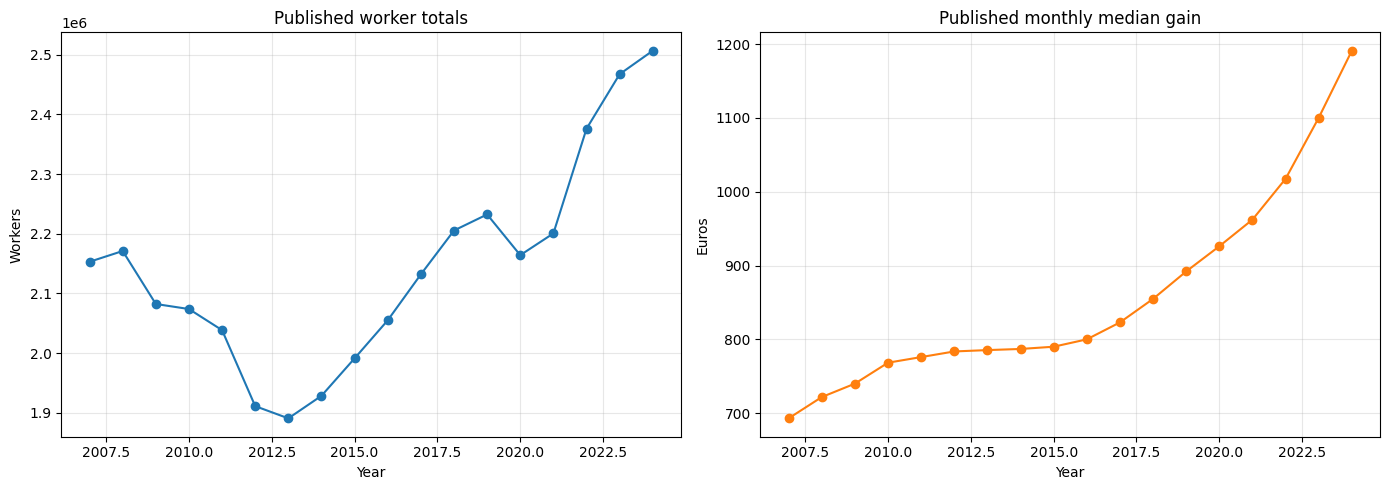

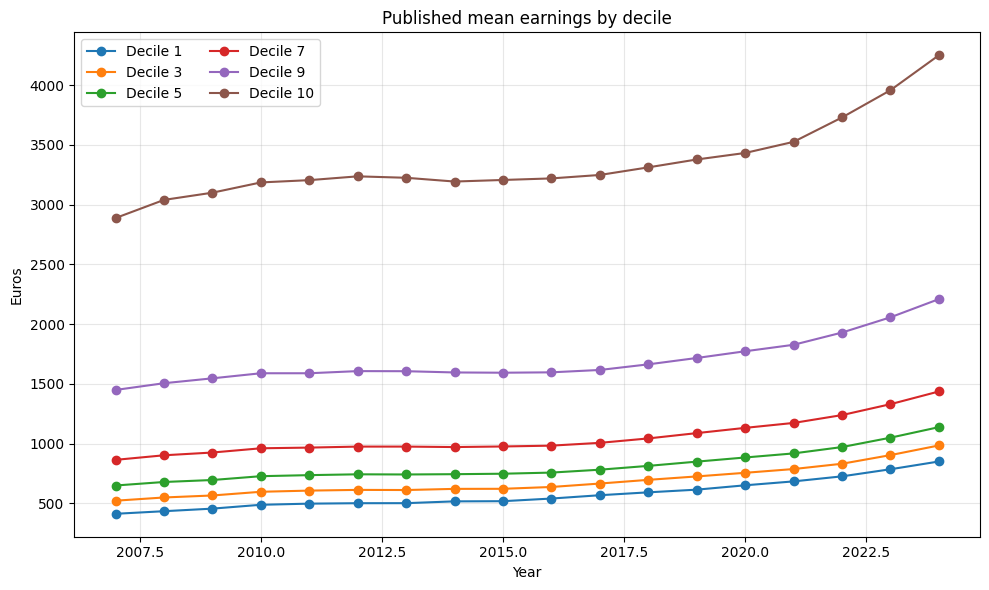

In [7]:
median_series = salary_summaries.query("statistic == 'median_gain'")[["year", "value"]].rename(columns={"value": "median_gain"})
decile_means = salary_summaries.query("statistic == 'mean_gain_by_decile'").copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(totals_comparison["year"], totals_comparison["total_workers"], marker="o")
axes[0].set_title("Published worker totals")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Workers")
axes[0].grid(True, alpha=0.3)

axes[1].plot(median_series["year"], median_series["median_gain"], marker="o", color="tab:orange")
axes[1].set_title("Published monthly median gain")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Euros")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "context_totals_and_median.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
for decile in [1, 3, 5, 7, 9, 10]:
    series = decile_means.query("decile == @decile").sort_values("year")
    ax.plot(series["year"], series["value"], marker="o", label=f"Decile {decile}")
ax.set_title("Published mean earnings by decile")
ax.set_xlabel("Year")
ax.set_ylabel("Euros")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "context_decile_means.png", dpi=160)
plt.show()

Two points matter here. First, this is a strongly **nominally trending** series, so cross-year comparisons should focus on shape and relative fit, not on unadjusted levels alone. Second, the widening distance between the lower deciles and the top decile is exactly the kind of feature that can make a single smooth family struggle.

## Real-wage context

The grouped-distribution fitting is still done year by year in nominal euros, which is appropriate for the likelihood step. But interpretation improves if we also show how the median and selected decile means evolve in real terms.

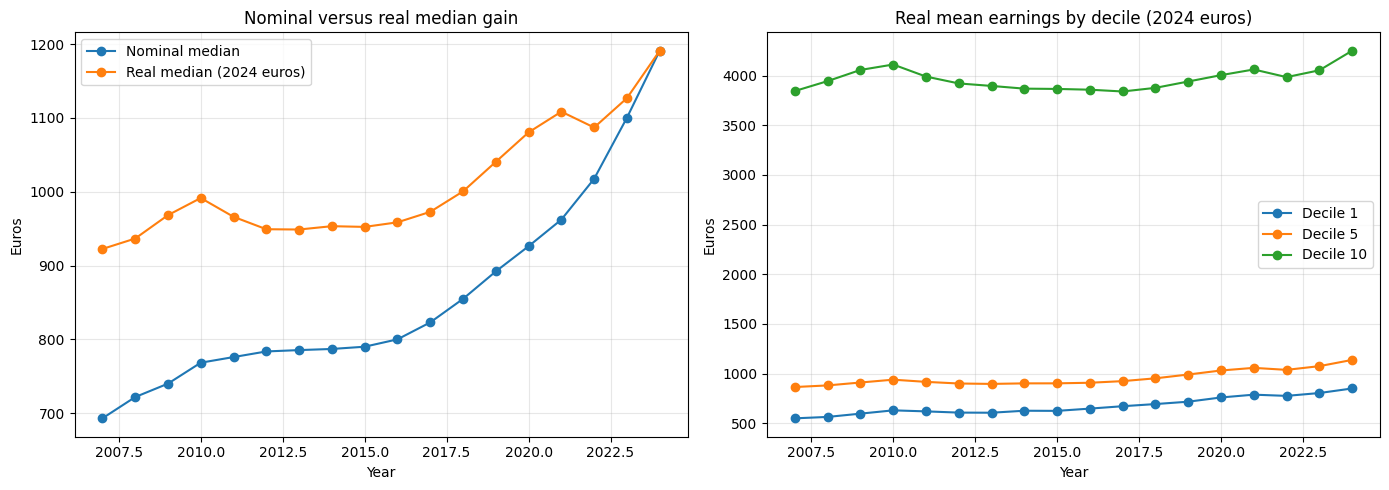

In [8]:
def download_world_bank_cpi(country: str = "PRT") -> pd.DataFrame:
    """Download annual CPI from the World Bank API."""
    url = f"https://api.worldbank.org/v2/country/{country}/indicator/FP.CPI.TOTL?format=json&per_page=20000"
    response = requests.get(url, timeout=60)
    response.raise_for_status()
    payload = response.json()
    rows: list[dict[str, float | int]] = []
    for item in payload[1]:
        if item.get("value") is None:
            continue
        rows.append({"year": int(item["date"]), "cpi": float(item["value"])})
    return pd.DataFrame(rows).sort_values("year")


try:
    cpi = download_world_bank_cpi()
    base_year = int(median_series["year"].max())
    base_cpi = float(cpi.loc[cpi["year"] == base_year, "cpi"].iloc[0])
    cpi["deflator_to_base_year"] = base_cpi / cpi["cpi"]
    cpi.to_csv(PROCESSED_DIR / "world_bank_cpi_portugal.csv", index=False)

    median_real = median_series.merge(cpi[["year", "deflator_to_base_year"]], on="year", how="left")
    median_real["median_gain_real"] = median_real["median_gain"] * median_real["deflator_to_base_year"]

    decile_real = decile_means.merge(cpi[["year", "deflator_to_base_year"]], on="year", how="left")
    decile_real["value_real"] = decile_real["value"] * decile_real["deflator_to_base_year"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(median_series["year"], median_series["median_gain"], marker="o", label="Nominal median")
    axes[0].plot(median_real["year"], median_real["median_gain_real"], marker="o", label=f"Real median ({base_year} euros)")
    axes[0].set_title("Nominal versus real median gain")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel("Euros")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    for decile in [1, 5, 10]:
        series = decile_real.query("decile == @decile").sort_values("year")
        axes[1].plot(series["year"], series["value_real"], marker="o", label=f"Decile {decile}")
    axes[1].set_title(f"Real mean earnings by decile ({base_year} euros)")
    axes[1].set_xlabel("Year")
    axes[1].set_ylabel("Euros")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "real_wage_context.png", dpi=160)
    plt.show()
except Exception as exc:
    print(f"Real-wage context skipped: {exc}")

This matters because a rising nominal scale parameter can reflect both genuine dispersion changes and price-level drift. The real-wage plots help distinguish wage-structure change from simple inflation arithmetic.

## Minimum-wage regime as a structural feature

The minimum wage is not just an inconvenience for fitting smooth distributions. It is one of the central institutional features shaping the Portuguese wage distribution, so it should be shown directly.

C:\Users\diogo\AppData\Local\Temp\ipykernel_30628\4217414387.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


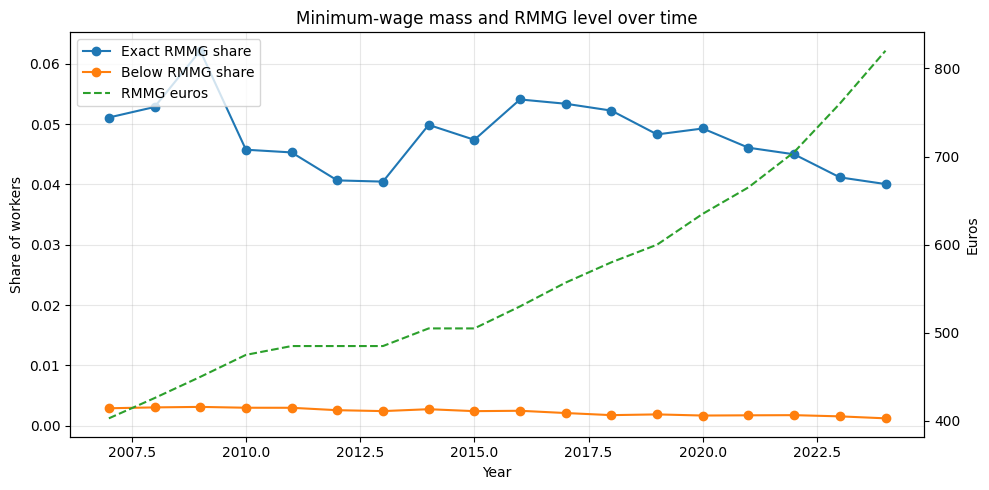

In [9]:
minimum_wage_context = (
    salary_bins.groupby("year")
    .apply(
        lambda group: pd.Series(
            {
                "share_below_rmmg": float(group.loc[group["bin_type"] == "below_minimum_wage", "count"].sum() / group["count"].sum()),
                "share_exact_rmmg": float(group.loc[group["bin_type"] == "exact_minimum_wage", "count"].sum() / group["count"].sum()),
                "rmmg_euros": float(RMMG_BY_YEAR[int(group.name)]),
            }
        )
    )
    .reset_index()
)
minimum_wage_context.to_csv(PROCESSED_DIR / "minimum_wage_context.csv", index=False)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(minimum_wage_context["year"], minimum_wage_context["share_exact_rmmg"], marker="o", label="Exact RMMG share", color="tab:blue")
ax1.plot(minimum_wage_context["year"], minimum_wage_context["share_below_rmmg"], marker="o", label="Below RMMG share", color="tab:orange")
ax1.set_xlabel("Year")
ax1.set_ylabel("Share of workers")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(minimum_wage_context["year"], minimum_wage_context["rmmg_euros"], color="tab:green", linestyle="--", label="RMMG euros")
ax2.set_ylabel("Euros")

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")
ax1.set_title("Minimum-wage mass and RMMG level over time")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "minimum_wage_regime.png", dpi=160)
plt.show()

This plot helps interpret why a single smooth positive-support distribution struggles. A visible mass exactly at the legal minimum wage is an institutional concentration, not the outcome of a smooth latent earnings process.

## Wage compression and spread

Distribution fitting is easier to interpret when paired with simple spread measures. Using the published mean earnings by decile, we can track how compressed or stretched the wage structure looks over time.

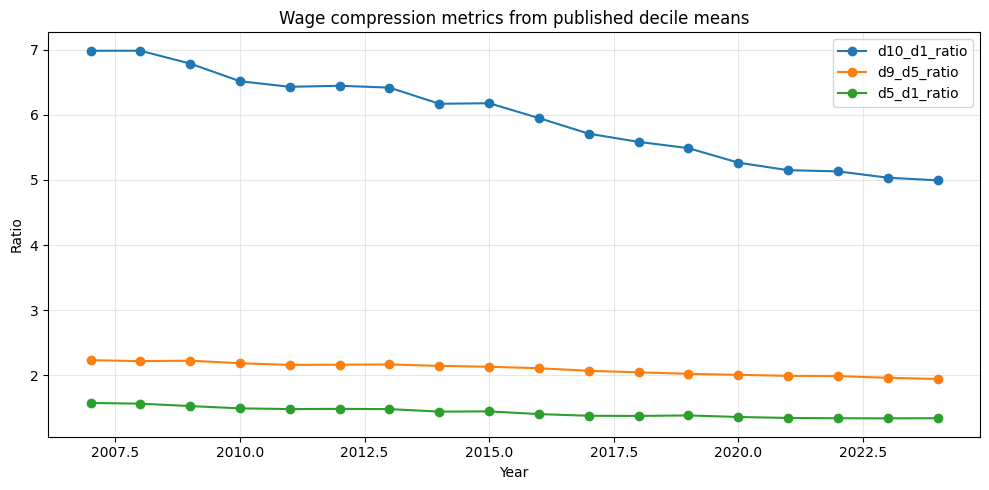

In [10]:
decile_pivot = decile_means.pivot(index="year", columns="decile", values="value").reset_index()
decile_pivot["d10_d1_ratio"] = decile_pivot[10.0] / decile_pivot[1.0]
decile_pivot["d9_d5_ratio"] = decile_pivot[9.0] / decile_pivot[5.0]
decile_pivot["d5_d1_ratio"] = decile_pivot[5.0] / decile_pivot[1.0]
compression_metrics = decile_pivot[["year", "d10_d1_ratio", "d9_d5_ratio", "d5_d1_ratio"]].copy()
compression_metrics.to_csv(PROCESSED_DIR / "wage_compression_metrics.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
for column in ["d10_d1_ratio", "d9_d5_ratio", "d5_d1_ratio"]:
    ax.plot(compression_metrics["year"], compression_metrics[column], marker="o", label=column)
ax.set_title("Wage compression metrics from published decile means")
ax.set_xlabel("Year")
ax.set_ylabel("Ratio")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "wage_compression_metrics.png", dpi=160)
plt.show()

These ratios help separate two stories: broad compression in the body of the distribution versus increasing stretch at the top. That distinction matters when deciding whether a model is missing the whole distribution or mainly the upper tail.

## Where did the distribution change?

Because the public bracket design changes over time, the cleanest way to compare the earliest and latest years is to use a harmonized set of broad earning bands rather than the raw publication bins.

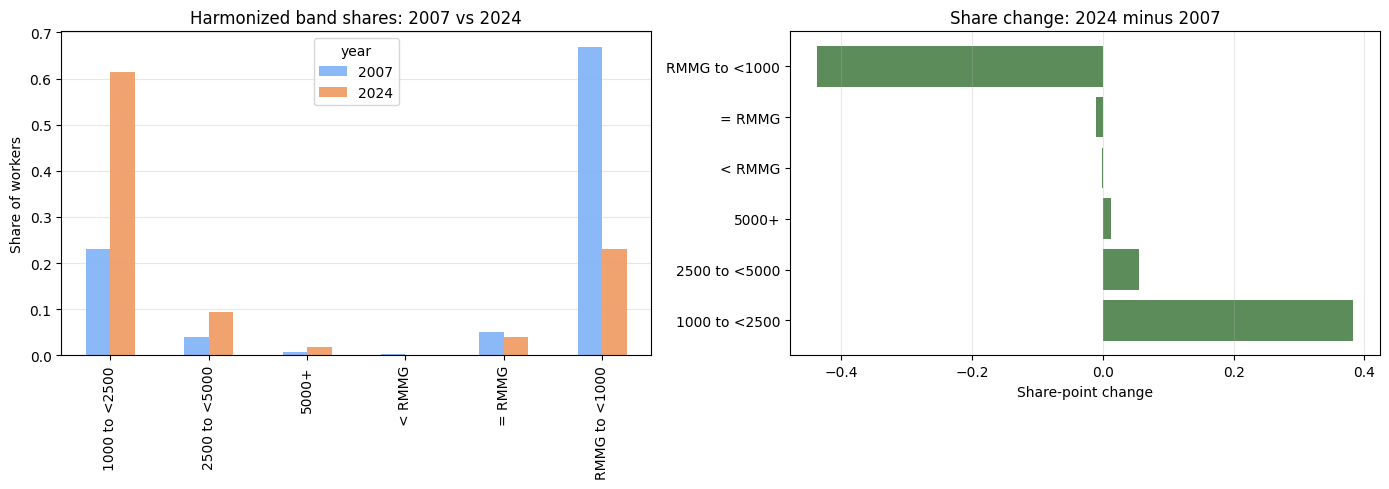

In [11]:
def harmonized_band(row: pd.Series) -> str:
    """Assign a raw salary bracket to a broad comparable band."""
    if row["bin_type"] == "below_minimum_wage":
        return "< RMMG"
    if row["bin_type"] == "exact_minimum_wage":
        return "= RMMG"
    if row["upper"] <= 1000.0:
        return "RMMG to <1000"
    if row["upper"] <= 2500.0:
        return "1000 to <2500"
    if np.isfinite(row["upper"]) and row["upper"] <= 5000.0:
        return "2500 to <5000"
    return "5000+"


harmonized_shares = salary_bins.copy()
harmonized_shares["broad_band"] = harmonized_shares.apply(harmonized_band, axis=1)
harmonized_shares = (
    harmonized_shares.groupby(["year", "broad_band"], as_index=False)["count"].sum()
    .assign(share=lambda df: df["count"] / df.groupby("year")["count"].transform("sum"))
)
harmonized_shares.to_csv(PROCESSED_DIR / "harmonized_broad_band_shares.csv", index=False)

first_year = int(harmonized_shares["year"].min())
last_year = int(harmonized_shares["year"].max())
share_change = (
    harmonized_shares.query("year in [@first_year, @last_year]")
    .pivot(index="broad_band", columns="year", values="share")
    .reset_index()
)
share_change["change_last_minus_first"] = share_change[last_year] - share_change[first_year]
share_change.to_csv(PROCESSED_DIR / "harmonized_share_change_first_last.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = share_change.set_index("broad_band")[[first_year, last_year]]
plot_df.plot(kind="bar", ax=axes[0], color=["#8bb8f7", "#f1a36f"])
axes[0].set_title(f"Harmonized band shares: {first_year} vs {last_year}")
axes[0].set_xlabel("")
axes[0].set_ylabel("Share of workers")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].barh(share_change["broad_band"], share_change["change_last_minus_first"], color="#5b8c5a")
axes[1].set_title(f"Share change: {last_year} minus {first_year}")
axes[1].set_xlabel("Share-point change")
axes[1].grid(True, axis="x", alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "distribution_change_harmonized_bands.png", dpi=160)
plt.show()

This section turns the abstract phrase “the distribution changed” into a concrete statement. It shows whether the main movement happened near the minimum wage, in the middle-income mass, or in the upper brackets.

## Fit grouped distributions by year

The main fitting step uses the published bracket counts. The equality mass at the minimum wage is excluded from the continuous grouped likelihood because a point mass cannot be represented cleanly by these smooth families.

In [12]:
fit_results = fit_year_models(salary_bins)
fit_results.to_csv(PROCESSED_DIR / "distribution_fit_results.csv", index=False)

winners = model_winners(fit_results)
winners.to_csv(PROCESSED_DIR / "model_winners_by_year.csv", index=False)

decile_fit = decile_validation(salary_summaries, fit_results)
decile_fit_summary = decile_validation_summary(decile_fit)
decile_fit.to_csv(PROCESSED_DIR / "decile_fit_validation.csv", index=False)
decile_fit_summary.to_csv(PROCESSED_DIR / "decile_fit_validation_summary.csv", index=False)

display(fit_results.head(12))
display(winners.head(12))

,year,model,n_bins,n_workers_used,nll,aic,bic,chi_square,chi_square_df,chi_square_p_value,converged,message,param_shape,param_scale,param_sigma,param_shape_a,param_shape_c
0,2007,gamma,9,2043004.0,4.091254e+06,8.182512e+06,8.182537e+06,5.361814e+06,6,0.0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,3.087730,316.341852,NaN,NaN,NaN
1,2007,lognormal,9,2043004.0,3.847485e+06,7.694974e+06,7.694999e+06,8.364065e+05,6,0.0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,NaN,824.479691,0.536191,NaN,NaN
2,2007,weibull,9,2043004.0,4.287803e+06,8.575611e+06,8.575636e+06,4.971666e+06,6,0.0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,1.557500,1103.741661,NaN,NaN,NaN
3,2007,generalized_gamma,9,2043004.0,3.927257e+06,7.854520e+06,7.854557e+06,1.266393e+06,5,0.0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,NaN,0.171264,NaN,23.471443,0.369653
4,2008,gamma,9,2056345.0,4.217439e+06,8.434883e+06,8.434908e+06,4.621965e+06,6,0.0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,3.103640,328.905623,NaN,NaN,NaN
5,2008,lognormal,9,2056345.0,3.971373e+06,7.942750e+06,7.942775e+06,8.753049e+05,6,0.0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,NaN,862.048540,0.534760,NaN,NaN
6,2008,weibull,9,2056345.0,4.416263e+06,8.832530e+06,8.832555e+06,4.157867e+06,6,0.0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,1.562501,1154.157650,NaN,NaN,NaN
7,2008,generalized_gamma,9,2056345.0,4.050498e+06,8.101002e+06,8.101040e+06,1.295468e+06,5,0.0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,NaN,0.135335,NaN,24.564335,0.363145
8,2009,gamma,9,1952771.0,4.076767e+06,8.153539e+06,8.153564e+06,3.839933e+06,6,0.0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,3.149252,334.578261,NaN,NaN,NaN
9,2009,lognormal,9,1952771.0,3.844626e+06,7.689255e+06,7.689280e+06,8.735933e+05,6,0.0,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,NaN,891.765600,0.531054,NaN,NaN


,year,winner_bic,winner_aic,bic_value,aic_value
0,2007,lognormal,lognormal,7.694999e+06,7.694974e+06
1,2008,lognormal,lognormal,7.942775e+06,7.942750e+06
2,2009,lognormal,lognormal,7.689280e+06,7.689255e+06
3,2010,lognormal,lognormal,6.638342e+06,6.638317e+06
4,2011,lognormal,lognormal,6.583933e+06,6.583908e+06
5,2012,lognormal,lognormal,6.218751e+06,6.218726e+06
6,2013,lognormal,lognormal,6.153697e+06,6.153672e+06
7,2014,lognormal,lognormal,4.636839e+06,4.636814e+06
8,2015,lognormal,lognormal,4.796904e+06,4.796879e+06
9,2016,lognormal,lognormal,5.032064e+06,5.032039e+06


## Main findings first

Before moving into diagnostics, it is useful to surface the current notebook result in one compact table. This keeps the rest of the notebook interpretive rather than suspense-driven.

In [13]:
main_findings = pd.DataFrame(
    [
        {"finding": "Public grouped-analysis window", "value": f"{int(salary_bins['year'].min())}-{int(salary_bins['year'].max())}"},
        {"finding": "Most frequent BIC winner", "value": winners["winner_bic"].mode().iloc[0]},
        {
            "finding": "Median Gamma decile error",
            "value": round(float(decile_fit_summary.query("model == 'gamma'")["mean_abs_relative_error"].median()), 4),
        },
        {
            "finding": "Median Lognormal decile error",
            "value": round(float(decile_fit_summary.query("model == 'lognormal'")["mean_abs_relative_error"].median()), 4),
        },
        {
            "finding": "Maximum total-count mismatch after extraction",
            "value": int(abs(totals_comparison["difference"]).max()),
        },
    ]
)
main_findings.to_csv(PROCESSED_DIR / "main_findings_first.csv", index=False)
display(main_findings)

,finding,value
0,Public grouped-analysis window,2007-2024
1,Most frequent BIC winner,lognormal
2,Median Gamma decile error,0.2013
3,Median Lognormal decile error,0.1439
4,Maximum total-count mismatch after extraction,0


This table is the notebook’s top-line answer. The later sections explain *why* the models differ, and where Gamma remains useful as a benchmark despite not winning the grouped-data competition.

AIC and BIC should not be read as metaphysical truth. They answer a narrower question: **which candidate family assigns the most likelihood to the published grouped counts, after penalizing complexity?** That is still very useful, because it turns the Gamma claim into a directly testable statement.

## Model competition over time

This section shows whether one family is consistently better or whether the winner changes over time. A changing winner usually means the data shape is not stable enough to justify one universal distributional claim.

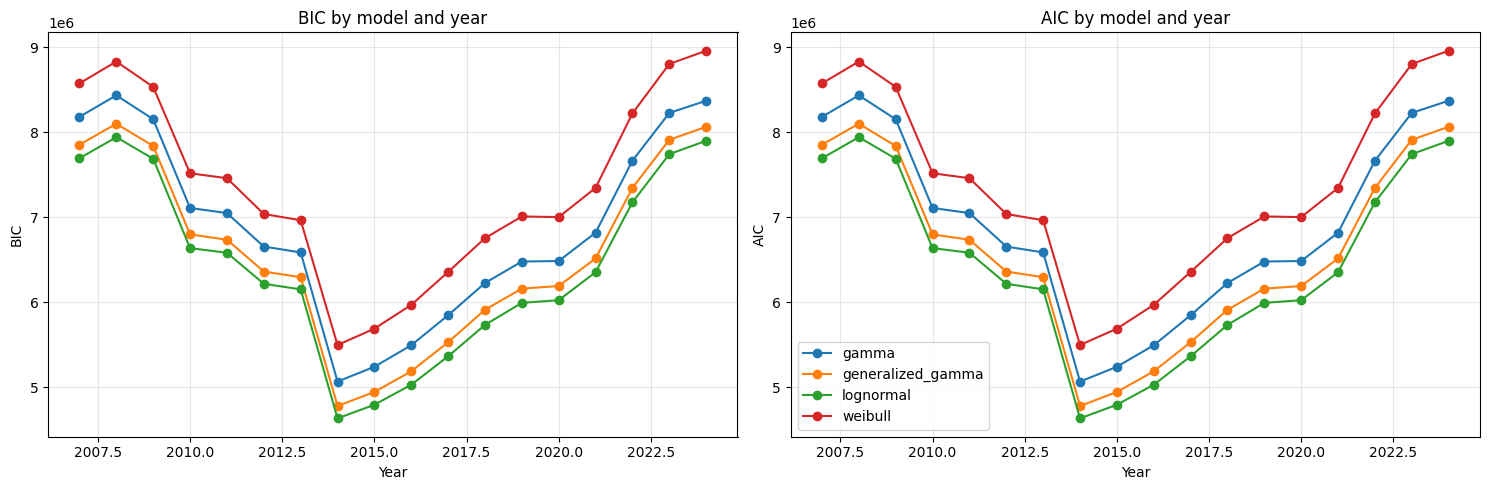

,model,n_years_bic_winner
0,lognormal,18


In [14]:
comparison_plot = fit_results.copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for model_name, model_df in comparison_plot.groupby("model"):
    axes[0].plot(model_df["year"], model_df["bic"], marker="o", label=model_name)
    axes[1].plot(model_df["year"], model_df["aic"], marker="o", label=model_name)

axes[0].set_title("BIC by model and year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("BIC")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("AIC by model and year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("AIC")
axes[1].grid(True, alpha=0.3)

axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "aic_bic_model_comparison.png", dpi=160)
plt.show()

winner_counts = winners["winner_bic"].value_counts().rename_axis("model").reset_index(name="n_years_bic_winner")
display(winner_counts)

If Gamma wins rarely, the right conclusion is not that Gamma is useless. The right conclusion is narrower: Gamma may still be a decent approximation for the body of the distribution, but it is not the best full grouped-data summary across years.

## How far ahead is the winning model?

Saying that one model wins is not enough. The next question is whether it wins narrowly or decisively. The plot below compares the BIC gap between **Gamma** and **Lognormal** over time. Positive values mean Lognormal fits the grouped public distribution better.

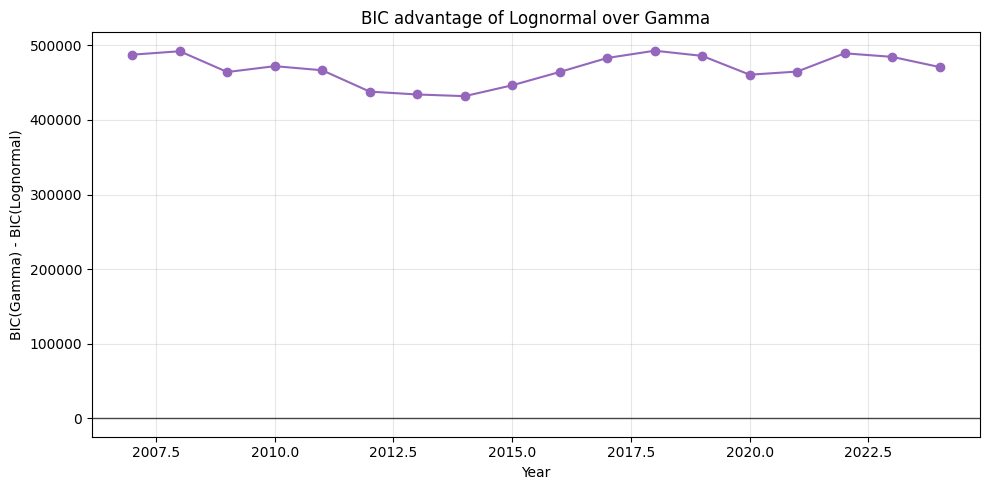

In [15]:
bic_gap = (
    fit_results.pivot(index="year", columns="model", values="bic")
    .reset_index()
    .assign(lognormal_minus_gamma=lambda df: df["gamma"] - df["lognormal"])
)
bic_gap.to_csv(PROCESSED_DIR / "bic_gap_gamma_vs_lognormal.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(bic_gap["year"], bic_gap["lognormal_minus_gamma"], marker="o", color="tab:purple")
ax.axhline(0.0, color="black", linewidth=1, alpha=0.7)
ax.set_title("BIC advantage of Lognormal over Gamma")
ax.set_xlabel("Year")
ax.set_ylabel("BIC(Gamma) - BIC(Lognormal)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "bic_gap_gamma_vs_lognormal.png", dpi=160)
plt.show()

This matters because the notebook is not just reporting a symbolic winner. A large and persistent positive gap means the evidence against Gamma as the best grouped-data summary is not marginal. It is systematic.

## Sensitivity analysis: minimum wage, top bracket, and body-only fits

The next question is whether the current ranking is stable to reasonable grouped-data modeling choices. This section reruns the fits under alternative inclusion rules for the exact minimum-wage mass, the open top bracket, and the body-only distribution.

C:\Users\diogo\AppData\Local\Temp\ipykernel_30628\1484891292.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,scenario,year,winner_bic,winner_aic,gamma_minus_lognormal_bic
0,baseline,2007,lognormal,lognormal,487537.834700
1,baseline,2008,lognormal,lognormal,492133.174480
2,baseline,2009,lognormal,lognormal,464283.506594
3,baseline,2010,lognormal,lognormal,472133.952963
4,baseline,2011,lognormal,lognormal,466631.154234
5,baseline,2012,lognormal,lognormal,438019.416563
6,baseline,2013,lognormal,lognormal,434184.436712
7,baseline,2014,lognormal,lognormal,431938.286300
8,baseline,2015,lognormal,lognormal,446499.962164
9,baseline,2016,lognormal,lognormal,464348.719645


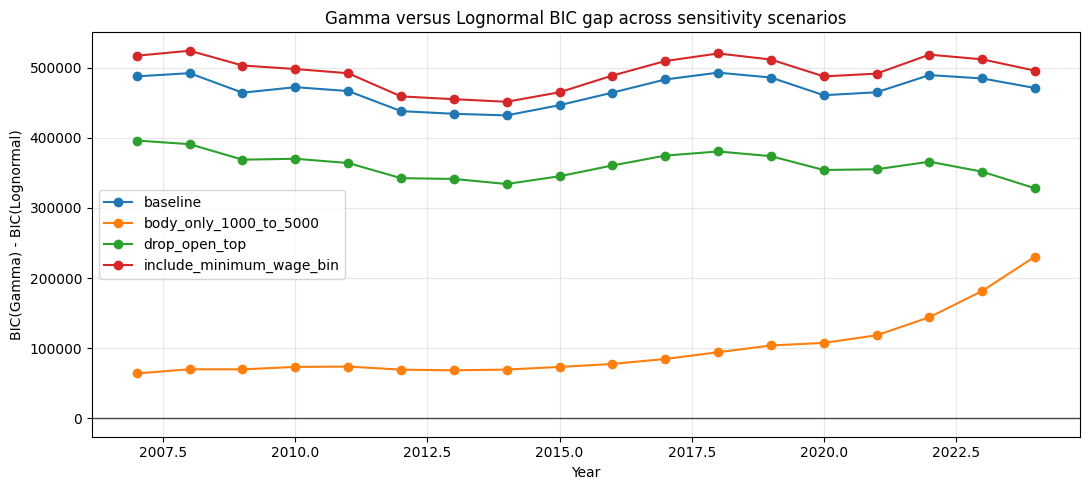

In [16]:
sensitivity_scenarios = {
    "baseline": {"drop_exact_minimum_wage": True},
    "include_minimum_wage_bin": {"drop_exact_minimum_wage": False},
    "drop_open_top": {"drop_exact_minimum_wage": True, "drop_open_top": True},
    "body_only_1000_to_5000": {
        "drop_exact_minimum_wage": True,
        "drop_open_top": True,
        "min_lower": 1000.0,
        "max_lower": 4999.99,
    },
}
sensitivity_results = fit_sensitivity_scenarios(salary_bins, sensitivity_scenarios)
sensitivity_results.to_csv(PROCESSED_DIR / "sensitivity_fit_results.csv", index=False)

sensitivity_summary = (
    sensitivity_results.groupby(["scenario", "year"], as_index=False)
    .apply(
        lambda group: pd.Series(
            {
                "winner_bic": str(group.sort_values("bic").iloc[0]["model"]),
                "winner_aic": str(group.sort_values("aic").iloc[0]["model"]),
                "gamma_minus_lognormal_bic": float(
                    group.loc[group["model"] == "gamma", "bic"].iloc[0]
                    - group.loc[group["model"] == "lognormal", "bic"].iloc[0]
                ),
            }
        )
    )
    .reset_index(drop=True)
)
sensitivity_summary.to_csv(PROCESSED_DIR / "sensitivity_summary.csv", index=False)
display(sensitivity_summary.head(12))

fig, ax = plt.subplots(figsize=(11, 5))
for scenario_name, scenario_df in sensitivity_summary.groupby("scenario"):
    ax.plot(scenario_df["year"], scenario_df["gamma_minus_lognormal_bic"], marker="o", label=scenario_name)
ax.axhline(0.0, color="black", linewidth=1, alpha=0.7)
ax.set_title("Gamma versus Lognormal BIC gap across sensitivity scenarios")
ax.set_xlabel("Year")
ax.set_ylabel("BIC(Gamma) - BIC(Lognormal)")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "sensitivity_gamma_vs_lognormal_bic_gap.png", dpi=160)
plt.show()

This section is doing the hard robustness work. If the ranking changes under mild and defensible grouped-data choices, the model conclusion is fragile. If the ranking stays stable, the grouped-data result becomes much stronger.

## Gamma parameter trends

Even when Gamma is not the overall winner, its parameters can still provide a compact description of how skewness and scale evolve. That is useful if the goal is to understand whether the distribution becomes more compressed or more spread out over time.

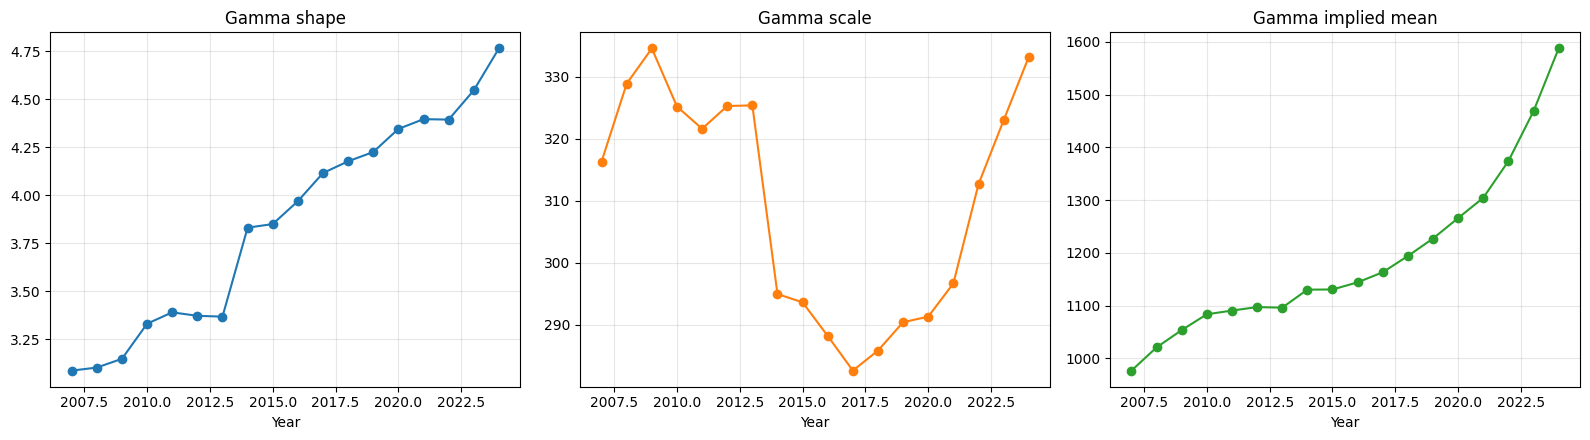

In [17]:
gamma_trend = gamma_parameter_trend(fit_results)
gamma_trend.to_csv(PROCESSED_DIR / "gamma_parameter_trend.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(gamma_trend["year"], gamma_trend["param_shape"], marker="o")
axes[0].set_title("Gamma shape")
axes[0].set_xlabel("Year")
axes[0].grid(True, alpha=0.3)

axes[1].plot(gamma_trend["year"], gamma_trend["param_scale"], marker="o", color="tab:orange")
axes[1].set_title("Gamma scale")
axes[1].set_xlabel("Year")
axes[1].grid(True, alpha=0.3)

axes[2].plot(gamma_trend["year"], gamma_trend["fitted_mean"], marker="o", color="tab:green")
axes[2].set_title("Gamma implied mean")
axes[2].set_xlabel("Year")
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "gamma_parameter_trends.png", dpi=160)
plt.show()

The most useful reading is comparative rather than absolute. A rising scale with limited shape movement suggests a general widening in the earnings scale. A collapsing shape would point to stronger skewness. The plot makes those tendencies visible without claiming Gamma is the one true model.

## Bootstrap parameter ranges for selected years

The fitted parameters are still point estimates. To give them some uncertainty context without turning the notebook into a long simulation exercise, this section uses a grouped multinomial bootstrap for representative years.

,year,model,parameter,n_boot,p10,p50,p90
0,2007,gamma,shape,12,3.082594,3.086952,3.089595
1,2007,gamma,scale,12,316.028984,316.444468,316.962875
2,2007,lognormal,sigma,12,0.535676,0.536024,0.536576
3,2007,lognormal,scale,12,824.072807,824.460229,824.671265
4,2016,gamma,shape,12,3.962483,3.970505,3.974410
5,2016,gamma,scale,12,287.781240,288.143949,289.012369
6,2016,lognormal,sigma,12,0.467381,0.467499,0.467742
7,2016,lognormal,scale,12,1003.107227,1003.321190,1003.557969
8,2024,gamma,shape,12,4.759065,4.765483,4.771606
9,2024,gamma,scale,12,332.595251,333.158703,333.714979


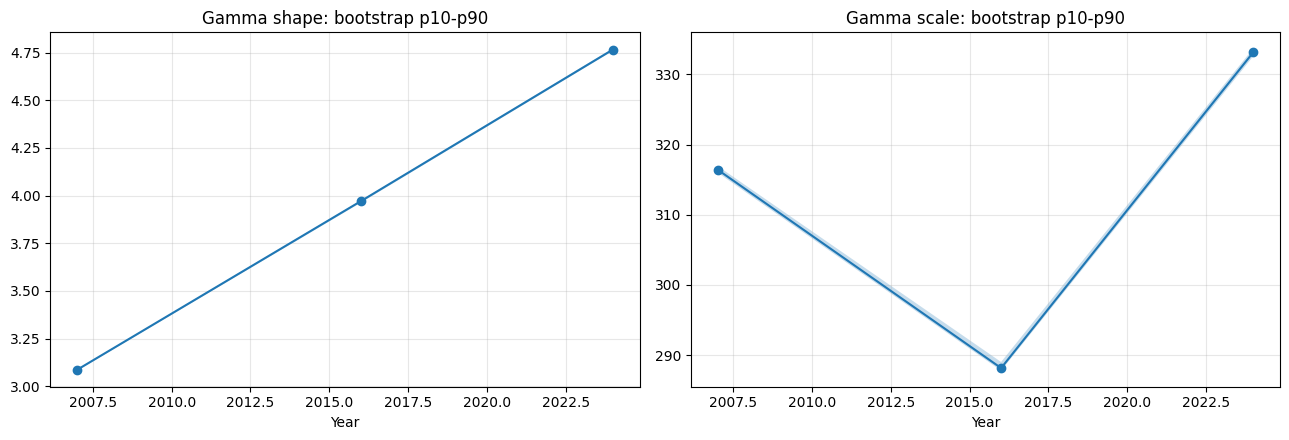

In [18]:
selected_years = representative_years(sorted(salary_bins["year"].unique()))
bootstrap_ranges = bootstrap_grouped_parameter_ranges(
    salary_bins,
    years=selected_years,
    models=["gamma", "lognormal"],
    n_boot=12,
    seed=42,
)
bootstrap_ranges.to_csv(PROCESSED_DIR / "bootstrap_parameter_ranges.csv", index=False)
display(bootstrap_ranges.head(12))

gamma_bootstrap = bootstrap_ranges.query("model == 'gamma'")
if not gamma_bootstrap.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for axis, parameter in zip(axes, ["shape", "scale"], strict=False):
        plot_df = gamma_bootstrap.query("parameter == @parameter").sort_values("year")
        axis.plot(plot_df["year"], plot_df["p50"], marker="o")
        axis.fill_between(plot_df["year"], plot_df["p10"], plot_df["p90"], alpha=0.25)
        axis.set_title(f"Gamma {parameter}: bootstrap p10-p90")
        axis.set_xlabel("Year")
        axis.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "gamma_bootstrap_ranges.png", dpi=160)
    plt.show()

These are not formal confidence intervals, but they do answer a practical question: are the fitted parameters so unstable that the apparent year-to-year movement is mostly noise? For the notebook’s purpose, that is the right level of uncertainty check.

## Histogram-style views of the published distribution

The public source does not provide worker-level microdata, so a literal microdata histogram is not available here. The defensible substitute is a **grouped histogram** built from the published salary brackets: each bar width is the bracket width and each bar area is the worker share in that bracket.

Because this is a salary-floor setting, the plotted support starts at the year-specific **RMMG** rather than at zero. Any published share below the minimum wage is shown as excluded context in the title area instead of being drawn to the left of the wage floor.

C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


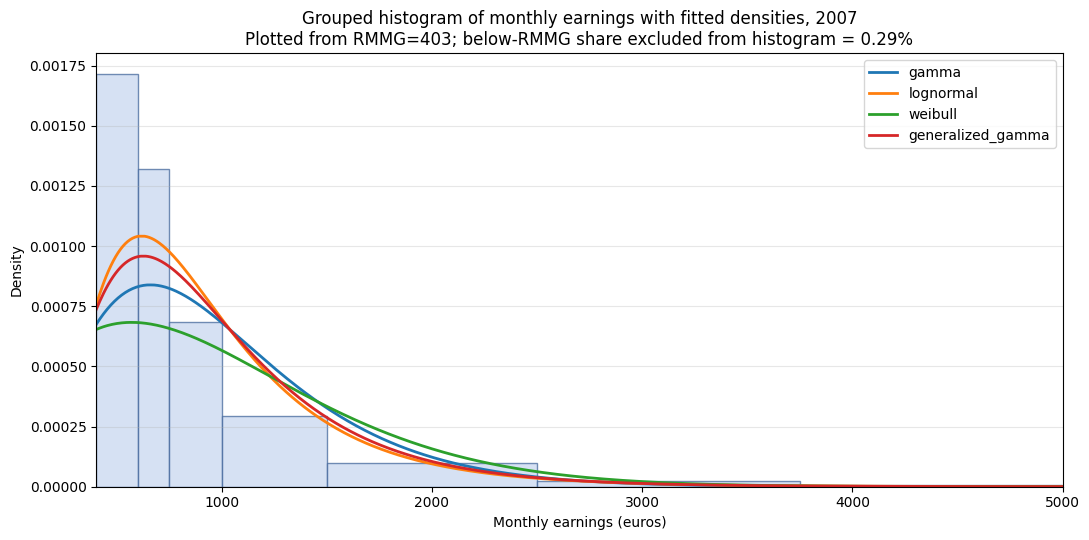

C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


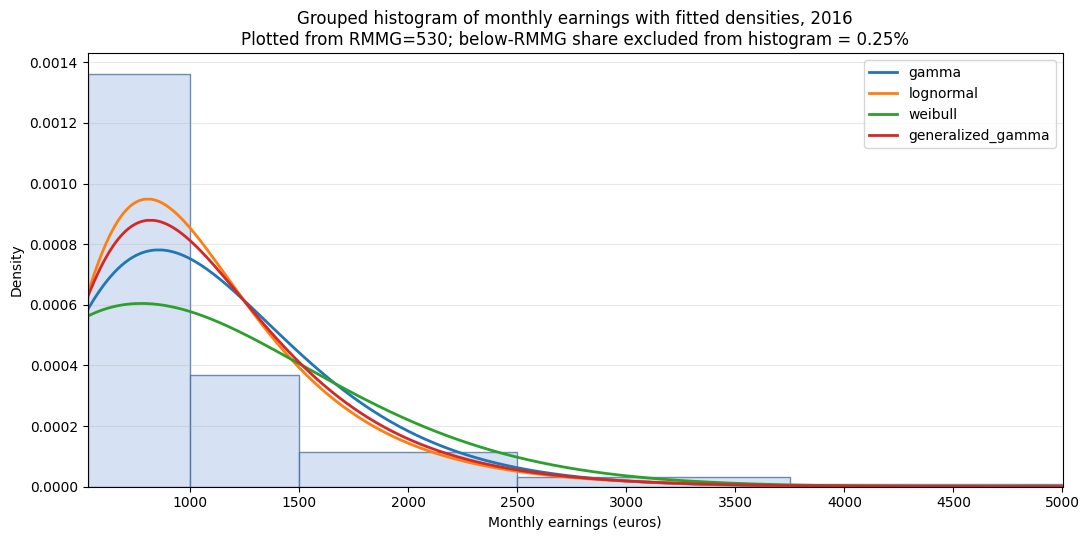

C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


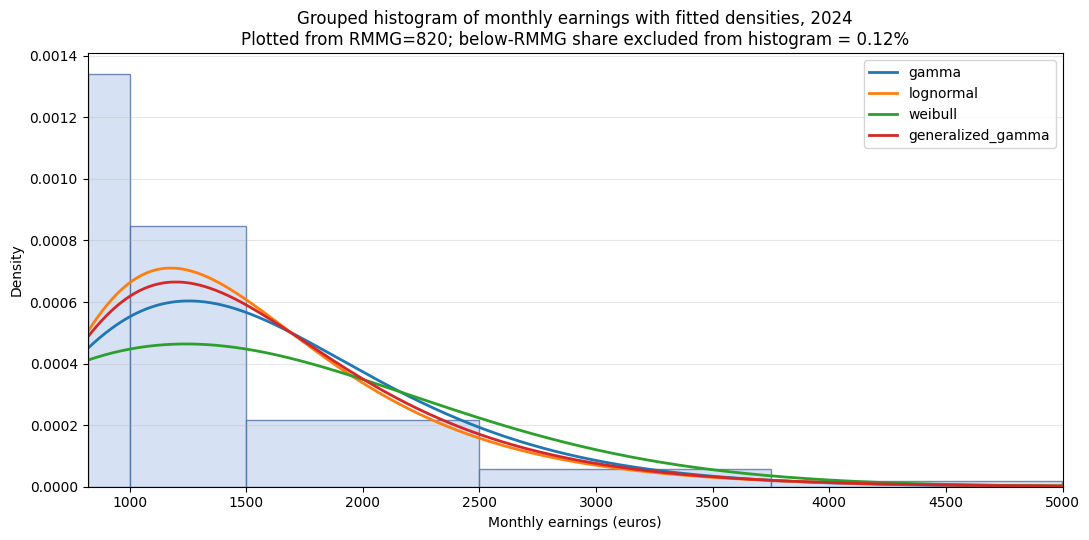

In [19]:
def frozen_from_row(row: pd.Series):
    """Build a scipy frozen distribution from a fitted-results row."""
    fit = fit_row_to_object(row)
    if fit.name == "gamma":
        return stats.gamma(a=fit.params["shape"], loc=0.0, scale=fit.params["scale"])
    if fit.name == "lognormal":
        return stats.lognorm(s=fit.params["sigma"], loc=0.0, scale=fit.params["scale"])
    if fit.name == "weibull":
        return stats.weibull_min(c=fit.params["shape"], loc=0.0, scale=fit.params["scale"])
    return stats.gengamma(
        a=fit.params["shape_a"],
        c=fit.params["shape_c"],
        loc=0.0,
        scale=fit.params["scale"],
    )


def plot_grouped_histogram_with_fits(year: int, x_cap: float = 5000.0) -> None:
    """Plot a grouped-data histogram with fitted model density overlays."""
    rmmg = float(RMMG_BY_YEAR[year])
    excluded_share = float(
        salary_bins.query("year == @year and bin_type == 'below_minimum_wage'")["count"].sum()
        / salary_bins.query("year == @year")["count"].sum()
    )
    year_bins = salary_bins.query("year == @year and bin_type not in ['below_minimum_wage', 'exact_minimum_wage']").copy()
    year_bins = grouped_histogram_frame(year_bins.query("count > 0").sort_values("lower").copy(), x_cap=x_cap)

    x = np.linspace(rmmg, x_cap, 800)
    fig, ax = plt.subplots(figsize=(11, 5.5))

    for row in year_bins.itertuples(index=False):
        ax.bar(
            row.lower,
            row.density_height,
            width=row.width,
            align="edge",
            color="#c9d7f0",
            edgecolor="#45689c",
            alpha=0.75,
        )

    for model_name in ["gamma", "lognormal", "weibull", "generalized_gamma"]:
        result_row = fit_results.query("year == @year and model == @model_name").iloc[0]
        frozen = frozen_from_row(result_row)
        density = clipped_density(frozen.pdf(x))
        ax.plot(x, density, linewidth=2, label=model_name)

    ax.set_title(
        f"Grouped histogram of monthly earnings with fitted densities, {year}\n"
        f"Plotted from RMMG={rmmg:.0f}; below-RMMG share excluded from histogram = {excluded_share:.2%}"
    )
    ax.set_xlabel("Monthly earnings (euros)")
    ax.set_ylabel("Density")
    ax.set_xlim(rmmg, x_cap)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"grouped_histogram_with_fits_{year}.png", dpi=160)
    plt.show()


for year in selected_years:
    plot_grouped_histogram_with_fits(year)

These are not synthetic visual extras. They are the main shape plots for grouped public data. If one model systematically overshoots the middle brackets or undershoots the upper tail, it becomes visible here immediately in a way that AIC and BIC alone do not show.

## Bracket-level residual diagnostics

Global information criteria can hide where the misspecification sits. Grouped Pearson residuals show whether models fail mostly near the minimum wage, in the upper middle, or in the top tail.

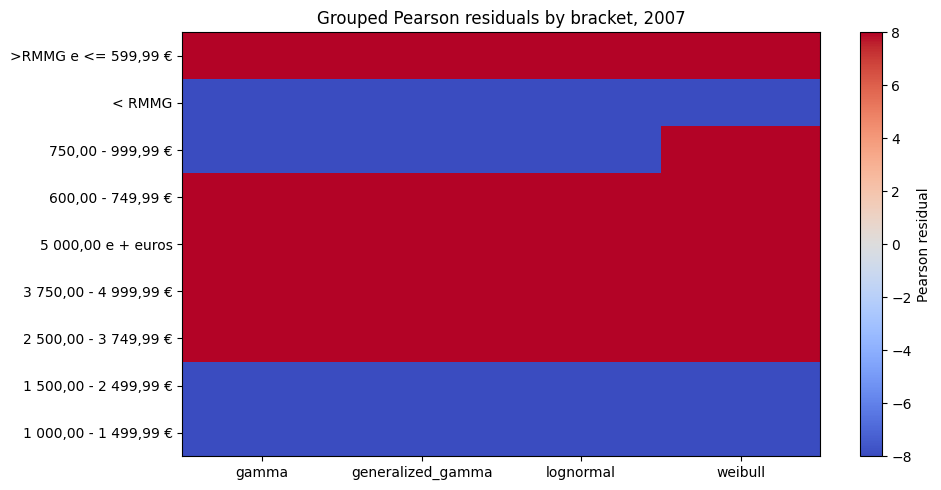

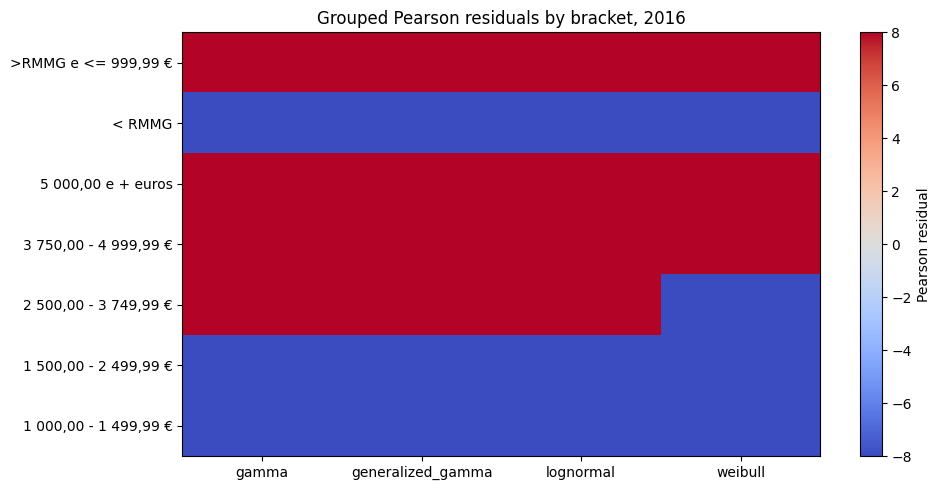

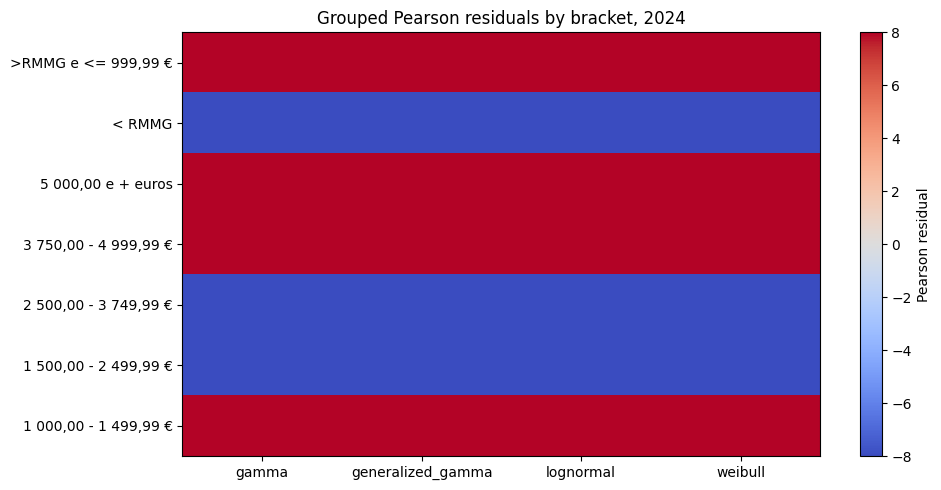

In [20]:
residuals = grouped_residuals(salary_bins, fit_results)
residuals.to_csv(PROCESSED_DIR / "grouped_residuals_by_bin.csv", index=False)

for year in selected_years:
    pivot = (
        residuals.query("year == @year")
        .pivot(index="bin_label", columns="model", values="pearson_residual")
        .sort_index(ascending=False)
    )
    fig, ax = plt.subplots(figsize=(10, 5))
    image = ax.imshow(pivot.to_numpy(dtype=float), aspect="auto", cmap="coolwarm", vmin=-8, vmax=8)
    ax.set_title(f"Grouped Pearson residuals by bracket, {year}")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    fig.colorbar(image, ax=ax, label="Pearson residual")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"grouped_residuals_{year}.png", dpi=160)
    plt.show()

A clean residual picture would look like random noise around zero. A systematic block of positive residuals in the upper brackets means the model is underfitting the top tail. A large pattern around the minimum wage usually means institutional wage-setting is breaking the smooth-distribution assumption.

## Observed versus fitted decile means

The grouped brackets drive the likelihood, but the decile means are an external validation layer. A model that wins on AIC/BIC and still misses decile means badly is not a convincing summary of the public distribution.

,year,model,mean_abs_relative_error,max_abs_relative_error,rmse
0,2007,gamma,0.200778,0.373380,270.410022
1,2007,generalized_gamma,0.159404,0.269234,248.015400
2,2007,lognormal,0.137060,0.240427,239.235275
3,2007,weibull,0.250442,0.621863,253.989236
4,2008,gamma,0.202282,0.374977,290.010167
5,2008,generalized_gamma,0.160139,0.269609,267.877117
6,2008,lognormal,0.138232,0.247499,258.035304
7,2008,weibull,0.253014,0.622057,272.384249
8,2009,gamma,0.207431,0.377592,294.605650
9,2009,generalized_gamma,0.165725,0.274735,271.215055


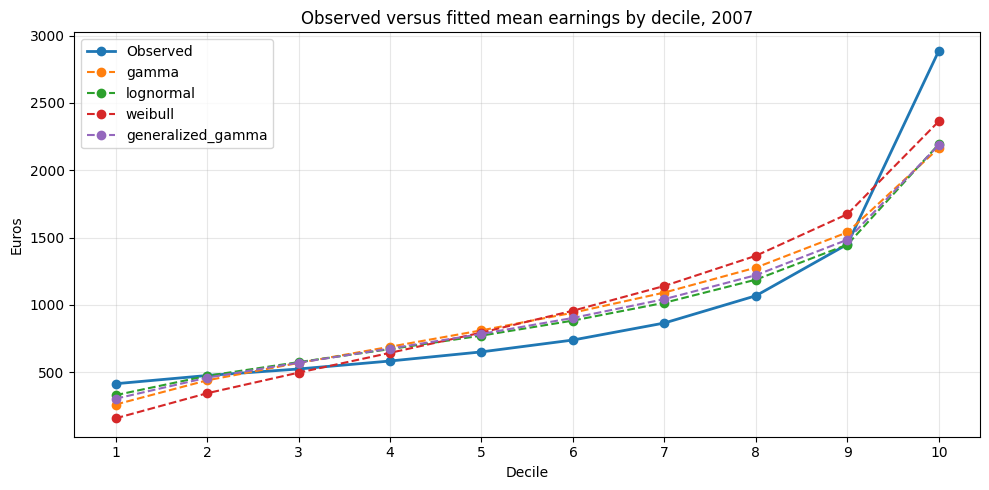

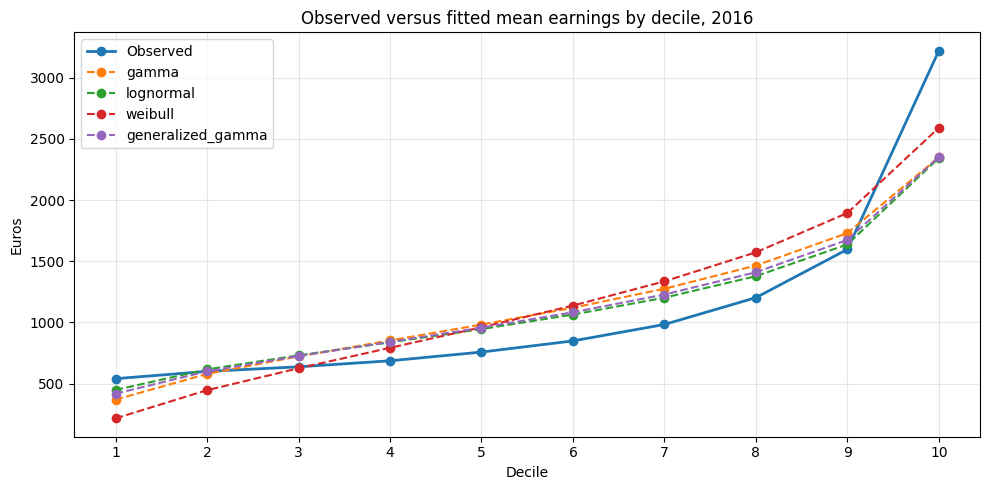

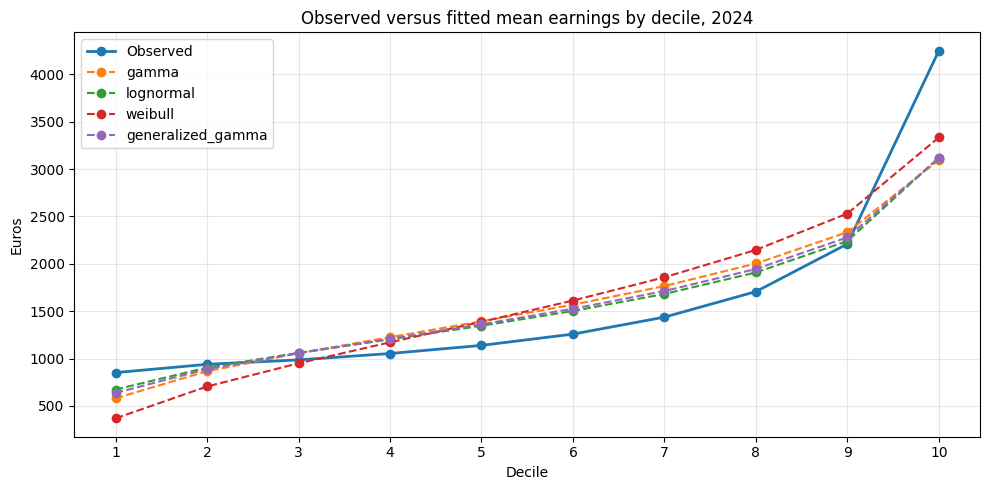

In [21]:
display(decile_fit_summary.head(12))

for year in selected_years:
    fig, ax = plt.subplots(figsize=(10, 5))
    observed = decile_fit.query("year == @year and model == 'gamma'").sort_values("decile")
    if observed.empty:
        continue
    ax.plot(observed["decile"], observed["observed_mean_gain"], marker="o", linewidth=2, label="Observed")
    for model_name in ["gamma", "lognormal", "weibull", "generalized_gamma"]:
        model_df = decile_fit.query("year == @year and model == @model_name").sort_values("decile")
        if model_df.empty:
            continue
        ax.plot(model_df["decile"], model_df["fitted_mean_gain"], marker="o", linestyle="--", label=model_name)
    ax.set_title(f"Observed versus fitted mean earnings by decile, {year}")
    ax.set_xlabel("Decile")
    ax.set_ylabel("Euros")
    ax.set_xticks(range(1, 11))
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"decile_validation_{year}.png", dpi=160)
    plt.show()

This is the most intuitive validation layer in the notebook. If a model fits the grouped counts but misses the upper-decile means badly, it is likely getting the **shape of the tail** wrong even if the bracket likelihood looks competitive.

## Decile-fit error over time

The next plot compresses the decile validation into one time series per model. Lower values mean the model is closer to the published mean earnings inside each decile.

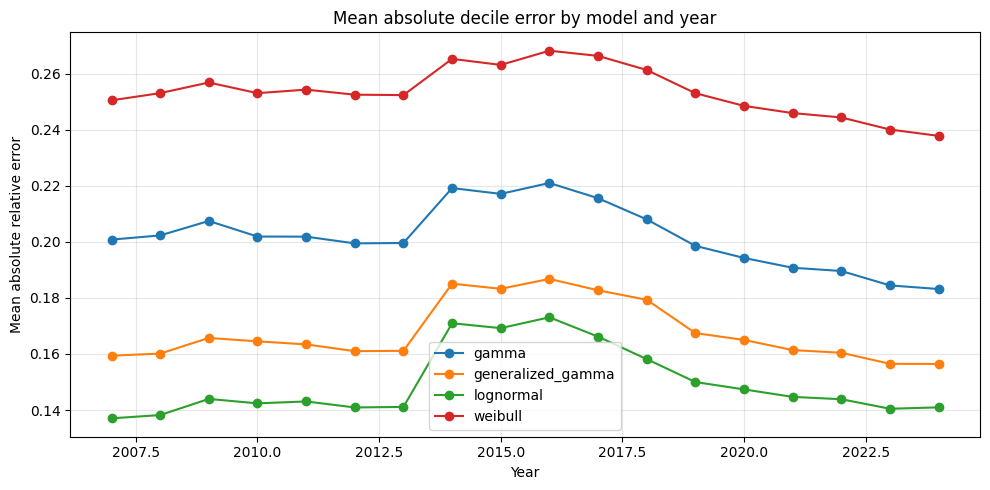

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
for model_name, model_df in decile_fit_summary.groupby("model"):
    ax.plot(model_df["year"], model_df["mean_abs_relative_error"], marker="o", label=model_name)
ax.set_title("Mean absolute decile error by model and year")
ax.set_xlabel("Year")
ax.set_ylabel("Mean absolute relative error")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "decile_error_by_model_over_time.png", dpi=160)
plt.show()

This is the clearest out-of-sample comparison in the notebook. If one model wins the grouped likelihood and also keeps lower decile-mean error over time, that is much stronger evidence than an information-criterion win alone.

## Optional top-tail check: Pareto diagnostic

This is not part of the main AIC/BIC competition. It is a tail-only diagnostic built from the highest salary brackets. The purpose is to see whether the upper tail behaves like something heavier than the main body models suggest.

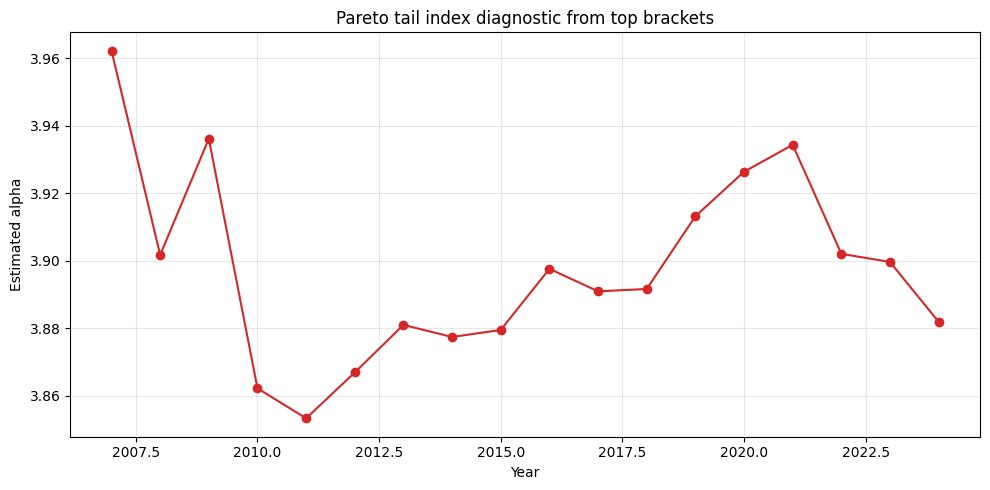

,year,tail_threshold,pareto_alpha,tail_worker_count,tail_worker_share
8,2015,3750.0,3.879508,39553.0,0.019865
9,2016,3750.0,3.897587,41446.0,0.020169
10,2017,3750.0,3.890944,43588.0,0.020445
11,2018,3750.0,3.891629,47387.0,0.021486
12,2019,3750.0,3.913158,50506.0,0.022624
13,2020,3750.0,3.926325,51019.0,0.023575
14,2021,3750.0,3.934304,56368.0,0.025615
15,2022,3750.0,3.902038,70430.0,0.029641
16,2023,3750.0,3.899632,86115.0,0.034898
17,2024,3750.0,3.881895,106835.0,0.042616


In [23]:
tail_diagnostics = pareto_tail_diagnostics(salary_bins)
tail_diagnostics.to_csv(PROCESSED_DIR / "pareto_tail_diagnostics.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tail_diagnostics["year"], tail_diagnostics["pareto_alpha"], marker="o", color="tab:red")
ax.set_title("Pareto tail index diagnostic from top brackets")
ax.set_xlabel("Year")
ax.set_ylabel("Estimated alpha")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "pareto_tail_alpha.png", dpi=160)
plt.show()

display(tail_diagnostics.tail(10))

Lower Pareto alpha means a heavier top tail. This diagnostic should be read cautiously because it is built from grouped top bins, not individual top incomes. Still, it adds useful context when smooth full-distribution models systematically miss the last brackets.

## Tail-only model comparison

The Pareto diagnostic above is descriptive. This section goes one step further by comparing a conditional Lognormal tail and a Pareto tail on the upper brackets only. That helps test whether the notebook’s main misspecification is really a tail problem.

,year,tail_threshold,winner_bic,n_bins,n_workers_used,nll,aic,bic,converged,message,param_sigma,param_scale,param_alpha
1,2007,2500.0,pareto_tail,3,98801.0,85703.730967,171409.461934,171418.962797,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,NaN,NaN,2.756973
3,2007,3750.0,pareto_tail,2,33156.0,22587.653115,45177.306230,45185.715209,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,NaN,NaN,2.990499
5,2008,2500.0,pareto_tail,3,110476.0,97986.515326,195975.030652,195984.643205,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,NaN,NaN,2.654009
7,2008,3750.0,pareto_tail,2,38568.0,26448.019013,52898.038025,52906.598203,True,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,NaN,NaN,2.859713
9,2009,2500.0,pareto_tail,3,113075.0,100284.334799,200570.669598,200580.305405,True,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,NaN,NaN,2.668335
11,2009,3750.0,pareto_tail,2,39508.0,26995.817262,53993.634524,54002.218783,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,NaN,NaN,2.934196
13,2010,2500.0,pareto_tail,3,117932.0,104299.612631,208601.225262,208610.903126,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,NaN,NaN,2.647817
15,2010,3750.0,pareto_tail,2,40903.0,28148.776171,56299.552343,56308.171302,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,NaN,NaN,2.774033
17,2011,2500.0,pareto_tail,3,116126.0,103484.361789,206970.723578,206980.386009,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,NaN,NaN,2.616569
19,2011,3750.0,pareto_tail,2,40853.0,28134.330695,56270.661389,56279.279125,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,NaN,NaN,2.754713


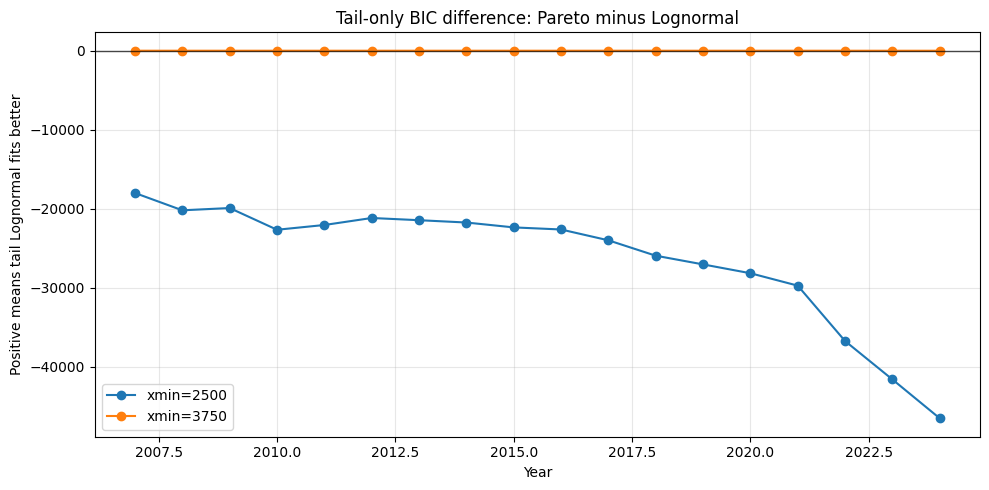

In [24]:
tail_comparison = tail_model_comparison(salary_bins)
tail_comparison.to_csv(PROCESSED_DIR / "tail_model_comparison.csv", index=False)

tail_winners = (
    tail_comparison.sort_values(["year", "tail_threshold", "bic"])
    .drop_duplicates(["year", "tail_threshold"], keep="first")
    .rename(columns={"model": "winner_bic"})
)
tail_winners.to_csv(PROCESSED_DIR / "tail_model_winners.csv", index=False)
display(tail_winners.head(12))

fig, ax = plt.subplots(figsize=(10, 5))
for threshold, threshold_df in tail_comparison.groupby("tail_threshold"):
    wide = threshold_df.pivot(index="year", columns="model", values="bic").reset_index()
    wide["pareto_minus_lognormal_tail"] = wide["pareto_tail"] - wide["lognormal_tail"]
    ax.plot(wide["year"], wide["pareto_minus_lognormal_tail"], marker="o", label=f"xmin={int(threshold)}")
ax.axhline(0.0, color="black", linewidth=1, alpha=0.7)
ax.set_title("Tail-only BIC difference: Pareto minus Lognormal")
ax.set_xlabel("Year")
ax.set_ylabel("Positive means tail Lognormal fits better")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "tail_model_comparison.png", dpi=160)
plt.show()

This section answers a narrower question than the full-distribution competition. Even if Lognormal wins overall, the upper tail may still behave more like a Pareto-type process beyond a sufficiently high threshold.

## Top-bracket concentration over time

The top-tail story is easier to read when shown directly in worker shares. This plot tracks the share of workers in the open top bracket and in the top two brackets combined.

C:\Users\diogo\AppData\Local\Temp\ipykernel_30628\1693153694.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


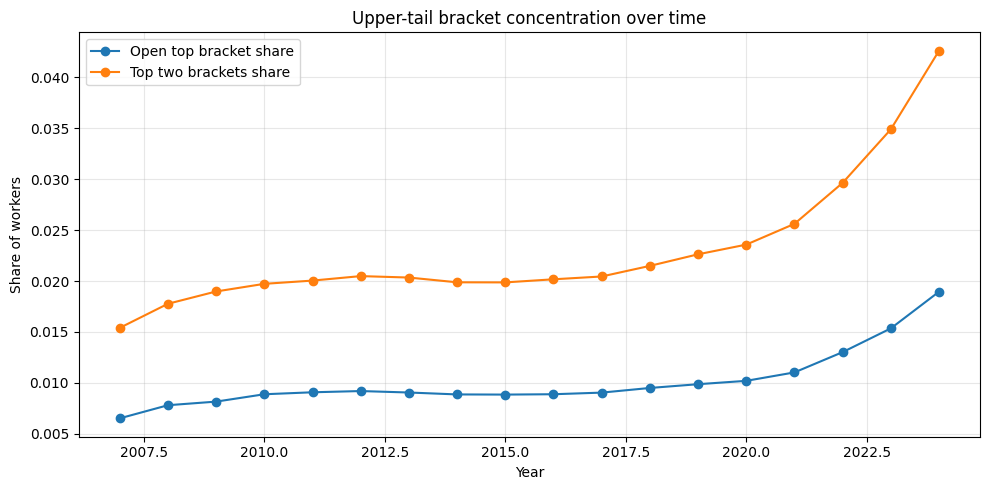

In [25]:
top_share = (
    salary_bins.assign(is_top_bracket=lambda df: df["bin_type"].eq("open_top"))
    .assign(is_top_two=lambda df: df["bin_type"].isin(["open_top", "closed_range"]) & (df["lower"] >= 3750.0))
    .groupby("year", as_index=False)
    .apply(
        lambda group: pd.Series(
            {
                "open_top_share": float(group.loc[group["bin_type"] == "open_top", "count"].sum() / group["count"].sum()),
                "top_two_brackets_share": float(group.loc[group["lower"] >= 3750.0, "count"].sum() / group["count"].sum()),
            }
        )
    )
    .reset_index(drop=True)
)
top_share.to_csv(PROCESSED_DIR / "top_bracket_shares_over_time.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(top_share["year"], top_share["open_top_share"], marker="o", label="Open top bracket share")
ax.plot(top_share["year"], top_share["top_two_brackets_share"], marker="o", label="Top two brackets share")
ax.set_title("Upper-tail bracket concentration over time")
ax.set_xlabel("Year")
ax.set_ylabel("Share of workers")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "top_bracket_shares_over_time.png", dpi=160)
plt.show()

This gives concrete distributional context to the tail diagnostics. The point is not that the top tail is huge in mass. The point is that even a small tail share can drive a large amount of misspecification when the right tail thickens over time.

## Observed versus fitted top-bracket shares

A direct way to test whether the full models miss the upper tail is to compare the observed top-bracket shares with the shares implied by each fitted model.

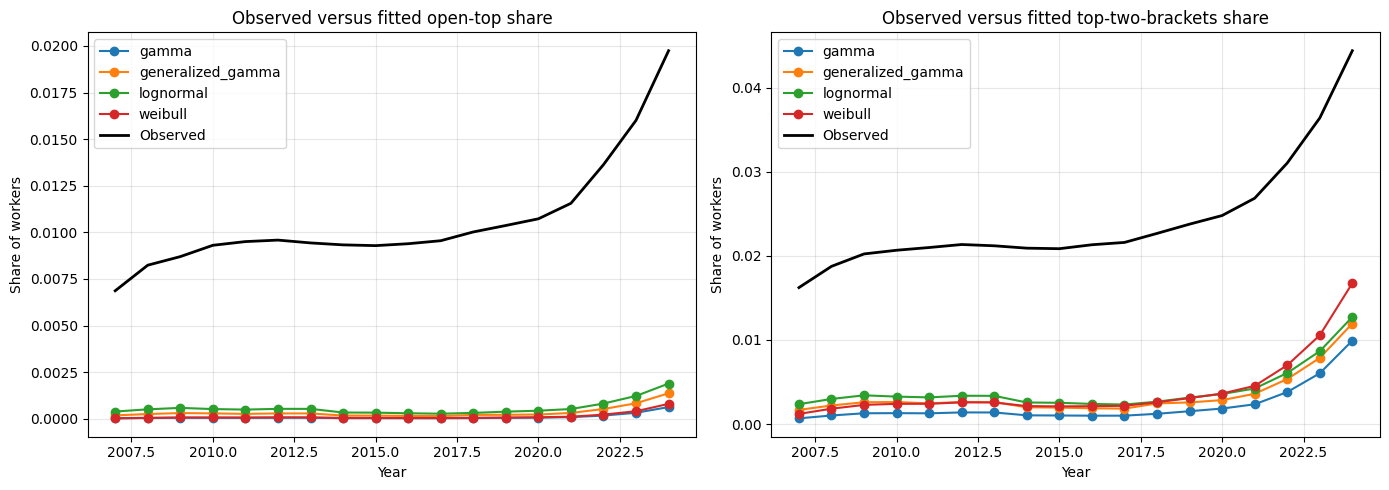

In [26]:
top_share_fit = top_share_fit_comparison(salary_bins, fit_results)
top_share_fit.to_csv(PROCESSED_DIR / "top_share_fit_comparison.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for model_name, model_df in top_share_fit.groupby("model"):
    axes[0].plot(model_df["year"], model_df["expected_open_top_share"], marker="o", label=model_name)
    axes[1].plot(model_df["year"], model_df["expected_top_two_share"], marker="o", label=model_name)

observed_top = top_share_fit.drop_duplicates("year").sort_values("year")
axes[0].plot(observed_top["year"], observed_top["observed_open_top_share"], color="black", linewidth=2, label="Observed")
axes[1].plot(observed_top["year"], observed_top["observed_top_two_share"], color="black", linewidth=2, label="Observed")

axes[0].set_title("Observed versus fitted open-top share")
axes[1].set_title("Observed versus fitted top-two-brackets share")
for ax in axes:
    ax.set_xlabel("Year")
    ax.set_ylabel("Share of workers")
    ax.grid(True, alpha=0.3)
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "observed_vs_fitted_top_shares.png", dpi=160)
plt.show()

This makes the tail misspecification concrete. A model can look broadly acceptable on grouped likelihood and still systematically overstate or understate the upper brackets in economically meaningful ways.

## Two-part splice model: Lognormal body plus Pareto tail

The one-family comparison answers a limited question: which single smooth family best approximates the grouped public distribution? The next question is whether a **two-part structure** does better: a Lognormal body up to a threshold, and a Pareto tail above that threshold.

This section fits that splice model directly and compares it against the current one-family benchmark.

,year,model,tail_threshold,n_bins,n_workers_used,nll,aic,bic,converged,message,param_body_sigma,param_body_scale,param_tail_alpha,param_tail_weight
0,2007,lognormal_pareto_splice,2500.0,9,2043004.0,3.724584e+06,7.449175e+06,7.449225e+06,True,body=CONVERGENCE: RELATIVE REDUCTION OF F <= F...,0.421686,764.009424,2.756973,0.048361
1,2007,lognormal_pareto_splice,3750.0,9,2043004.0,3.788299e+06,7.576606e+06,7.576656e+06,True,body=CONVERGENCE: RELATIVE REDUCTION OF F <= F...,0.484033,799.645952,2.990499,0.016229
2,2008,lognormal_pareto_splice,2500.0,9,2056345.0,3.834973e+06,7.669954e+06,7.670004e+06,True,body=CONVERGENCE: RELATIVE REDUCTION OF F <= F...,0.411674,792.430890,2.654009,0.053724
3,2008,lognormal_pareto_splice,3750.0,9,2056345.0,3.903352e+06,7.806712e+06,7.806762e+06,True,body=CONVERGENCE: RELATIVE REDUCTION OF F <= F...,0.476720,832.288487,2.859713,0.018756
4,2009,lognormal_pareto_splice,2500.0,9,1952771.0,3.707197e+06,7.414402e+06,7.414452e+06,True,body=CONVERGENCE: RELATIVE REDUCTION OF F <= F...,0.402814,815.085229,2.668335,0.057905
5,2009,lognormal_pareto_splice,3750.0,9,1952771.0,3.777106e+06,7.554220e+06,7.554270e+06,True,body=CONVERGENCE: RELATIVE REDUCTION OF F <= F...,0.470644,858.919223,2.934196,0.020232
6,2010,lognormal_pareto_splice,2500.0,8,1978878.0,3.159663e+06,6.319334e+06,6.319384e+06,True,body=CONVERGENCE: RELATIVE REDUCTION OF F <= F...,0.378823,849.037986,2.647817,0.059595
7,2010,lognormal_pareto_splice,3750.0,8,1978878.0,3.241809e+06,6.483626e+06,6.483676e+06,True,body=CONVERGENCE: RELATIVE REDUCTION OF F <= F...,0.450739,893.235470,2.774033,0.020670
8,2011,lognormal_pareto_splice,2500.0,8,1945988.0,3.128280e+06,6.256569e+06,6.256619e+06,True,body=CONVERGENCE: RELATIVE REDUCTION OF F <= F...,0.372991,856.656756,2.616569,0.059675
9,2011,lognormal_pareto_splice,3750.0,8,1945988.0,3.211261e+06,6.422530e+06,6.422580e+06,True,body=CONVERGENCE: RELATIVE REDUCTION OF F <= F...,0.444468,900.939591,2.754713,0.020993


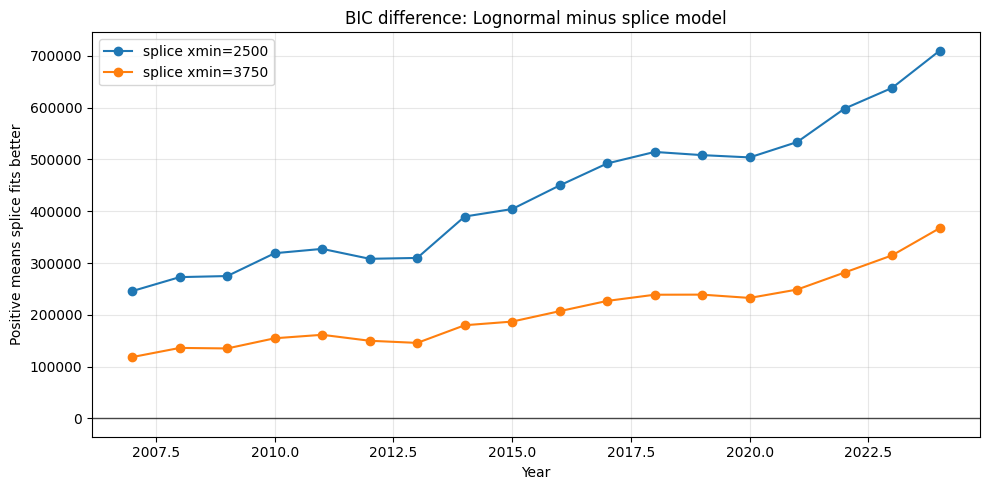

In [27]:
splice_results = fit_lognormal_pareto_splice_all_years(salary_bins)
splice_results.to_csv(PROCESSED_DIR / "splice_fit_results.csv", index=False)
display(splice_results.head(12))

splice_vs_lognormal = (
    splice_results.merge(
        fit_results.query("model == 'lognormal'")[["year", "bic", "aic", "nll"]],
        on="year",
        how="left",
        suffixes=("_splice", "_lognormal"),
    )
    .assign(
        bic_lognormal_minus_splice=lambda df: df["bic_lognormal"] - df["bic_splice"],
        aic_lognormal_minus_splice=lambda df: df["aic_lognormal"] - df["aic_splice"],
    )
)
splice_vs_lognormal.to_csv(PROCESSED_DIR / "splice_vs_lognormal.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
for threshold, threshold_df in splice_vs_lognormal.groupby("tail_threshold"):
    ax.plot(
        threshold_df["year"],
        threshold_df["bic_lognormal_minus_splice"],
        marker="o",
        label=f"splice xmin={int(threshold)}",
    )
ax.axhline(0.0, color="black", linewidth=1, alpha=0.7)
ax.set_title("BIC difference: Lognormal minus splice model")
ax.set_xlabel("Year")
ax.set_ylabel("Positive means splice fits better")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "splice_vs_lognormal_bic.png", dpi=160)
plt.show()

This is the main reason to fit the splice model at all. If the splice specification beats the one-family Lognormal by a meaningful margin, the notebook should report two different winners: the best one-family approximation and the best tail-aware approximation.

## Splice model and top-tail shares

A two-part model should improve upper-tail fit directly. The first check is whether it reproduces the observed top-bracket shares more closely than the one-family models.

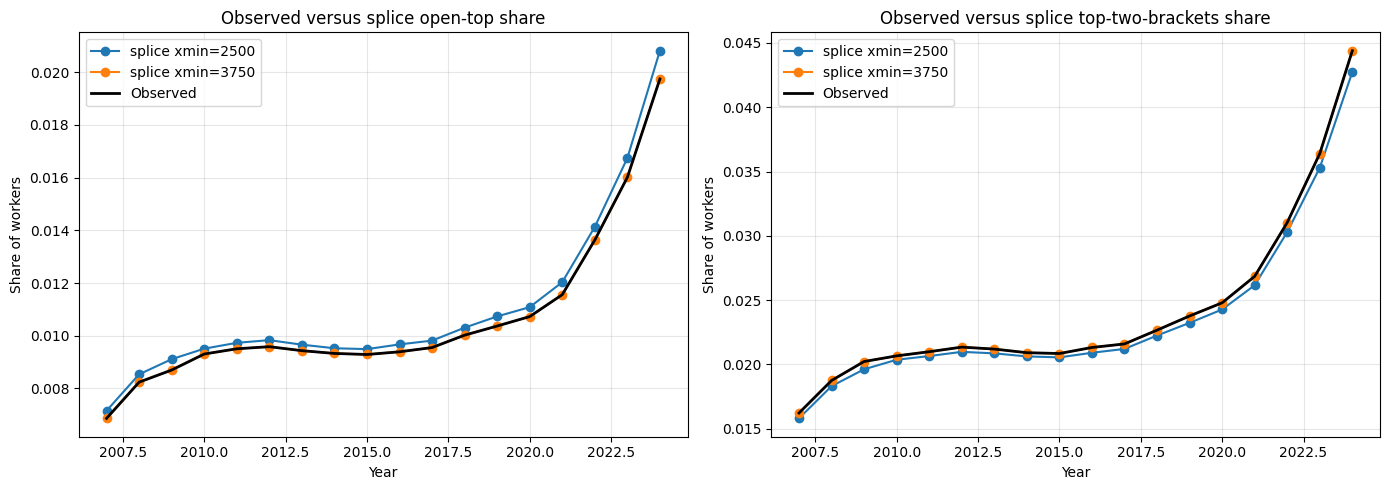

In [28]:
splice_top_shares = splice_top_share_comparison(salary_bins, splice_results)
splice_top_shares.to_csv(PROCESSED_DIR / "splice_top_share_comparison.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for threshold, threshold_df in splice_top_shares.groupby("tail_threshold"):
    axes[0].plot(threshold_df["year"], threshold_df["splice_open_top_share"], marker="o", label=f"splice xmin={int(threshold)}")
    axes[1].plot(threshold_df["year"], threshold_df["splice_top_two_share"], marker="o", label=f"splice xmin={int(threshold)}")

observed_splice_top = splice_top_shares.drop_duplicates("year").sort_values("year")
axes[0].plot(observed_splice_top["year"], observed_splice_top["observed_open_top_share"], color="black", linewidth=2, label="Observed")
axes[1].plot(observed_splice_top["year"], observed_splice_top["observed_top_two_share"], color="black", linewidth=2, label="Observed")

axes[0].set_title("Observed versus splice open-top share")
axes[1].set_title("Observed versus splice top-two-brackets share")
for ax in axes:
    ax.set_xlabel("Year")
    ax.set_ylabel("Share of workers")
    ax.grid(True, alpha=0.3)
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "splice_top_share_comparison.png", dpi=160)
plt.show()

If the splice model is worthwhile, these lines should move closer to the observed upper-tail shares than the one-family fits. That is the most direct economic case for preferring a two-part model.

## Splice model and top-decile diagnostics

Tail shares are not enough on their own. A tail-aware model should also improve the quantities people usually care about in the upper tail, especially the 90th-percentile cutoff and the mean earnings in the top decile.

,year,tail_threshold,observed_p90_cutpoint,splice_p90_cutpoint,observed_decile10_mean,splice_decile10_mean,p90_relative_error,decile10_mean_relative_error
0,2007,2500.0,NaN,1483.633797,2888.364821,2821.264866,NaN,-0.023231
1,2007,3750.0,NaN,1553.811744,2888.364821,2553.257384,NaN,-0.116020
2,2008,2500.0,NaN,1551.372255,3040.073922,3000.473961,NaN,-0.013026
3,2008,3750.0,NaN,1608.594803,3040.073922,2732.528656,NaN,-0.101164
4,2009,2500.0,NaN,1592.857820,3100.453183,3121.136395,NaN,0.006671
5,2009,3750.0,NaN,1647.367008,3100.453183,2806.664573,NaN,-0.094757
6,2010,2500.0,NaN,1607.750296,3186.296607,3129.610459,NaN,-0.017791
7,2010,3750.0,NaN,1676.202685,3186.296607,2843.125584,NaN,-0.107702
8,2011,2500.0,NaN,1611.949778,3205.418809,3175.444479,NaN,-0.009351
9,2011,3750.0,NaN,1674.240366,3205.418809,2867.982059,NaN,-0.105271


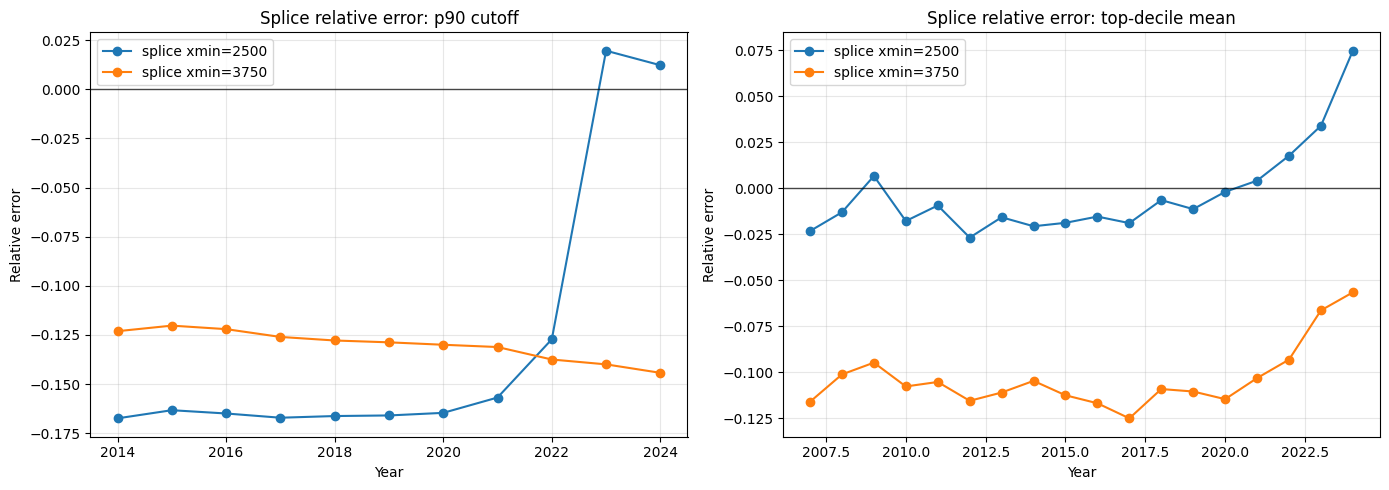

In [29]:
splice_top_decile = splice_top_decile_diagnostics(salary_summaries, splice_results, size=150000)
splice_top_decile.to_csv(PROCESSED_DIR / "splice_top_decile_diagnostics.csv", index=False)
display(splice_top_decile.head(12))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for threshold, threshold_df in splice_top_decile.groupby("tail_threshold"):
    axes[0].plot(threshold_df["year"], threshold_df["p90_relative_error"], marker="o", label=f"splice xmin={int(threshold)}")
    axes[1].plot(threshold_df["year"], threshold_df["decile10_mean_relative_error"], marker="o", label=f"splice xmin={int(threshold)}")

axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.7)
axes[1].axhline(0.0, color="black", linewidth=1, alpha=0.7)
axes[0].set_title("Splice relative error: p90 cutoff")
axes[1].set_title("Splice relative error: top-decile mean")
for ax in axes:
    ax.set_xlabel("Year")
    ax.set_ylabel("Relative error")
    ax.grid(True, alpha=0.3)
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "splice_top_decile_diagnostics.png", dpi=160)
plt.show()

This moves the splice model beyond a purely technical fit exercise. If it improves both top-bracket shares and top-decile quantities, then the notebook has strong evidence that the upper tail is governed by a different process from the wage body.

## Optional microdata branch

Public reproducibility should not depend on restricted microdata. Still, if a local anonymized file exists under `data/private/`, the package can fit a microdata branch for comparison. If no file exists, the notebook should skip cleanly.

In [30]:
microdata_schema = pd.DataFrame(
    [
        {"column": "year", "dtype": "integer", "required": True, "description": "Calendar year matching the public series."},
        {"column": "monthly_earnings", "dtype": "float", "required": True, "description": "Positive monthly earnings in euros."},
    ]
)
microdata_schema.to_csv(PROCESSED_DIR / "optional_microdata_schema.csv", index=False)
display(microdata_schema)

microdata_fit = optional_microdata_fit(PRIVATE_DIR)
if microdata_fit.empty:
    print(
        "No local anonymized microdata file found. "
        "The expected schema is documented in data/private/MICRODATA_SCHEMA.md "
        "and mirrored in data/processed/optional_microdata_schema.csv."
    )
else:
    microdata_fit.to_csv(PROCESSED_DIR / "optional_microdata_fit.csv", index=False)
    display(microdata_fit.head())

,column,dtype,required,description
0,year,integer,True,Calendar year matching the public series.
1,monthly_earnings,float,True,Positive monthly earnings in euros.


No local anonymized microdata file found. The expected schema is documented in data/private/MICRODATA_SCHEMA.md and mirrored in data/processed/optional_microdata_schema.csv.


This branch is deliberately optional. The public notebook should stand on its own, and the microdata path is only there for a future stronger replication if anonymized access becomes available.

## Compact final comparison

The notebook now contains three distinct model-selection layers:

- the best **one-family full-distribution** model;
- the best **tail-only** model;
- the best **tail-aware splice** model.

Putting them in one table makes the final reading much clearer.

In [31]:
best_splice_row = splice_vs_lognormal.sort_values("bic_splice").iloc[0]
best_tail_row = tail_winners.sort_values(["tail_threshold", "year"]).groupby("tail_threshold").first().reset_index().iloc[0]
comparison_summary = pd.DataFrame(
    [
        {
            "comparison_layer": "one_family_full_distribution",
            "preferred_model": winner_counts.sort_values("n_years_bic_winner", ascending=False).iloc[0]["model"],
            "selection_basis": "most yearly BIC wins",
            "key_statistic": int(winner_counts.sort_values("n_years_bic_winner", ascending=False).iloc[0]["n_years_bic_winner"]),
            "interpretation": "Best single smooth approximation to the grouped public distribution.",
        },
        {
            "comparison_layer": "tail_only",
            "preferred_model": str(best_tail_row["winner_bic"]),
            "selection_basis": "tail-only BIC at representative threshold",
            "key_statistic": float(best_tail_row["tail_threshold"]),
            "interpretation": "Best model when only the upper tail is fitted.",
        },
        {
            "comparison_layer": "tail_aware_splice",
            "preferred_model": "lognormal_pareto_splice",
            "selection_basis": "lowest splice BIC against one-family lognormal",
            "key_statistic": float(best_splice_row["tail_threshold"]),
            "interpretation": "Best model when the wage body and the upper tail are allowed to follow different processes.",
        },
    ]
)
comparison_summary.to_csv(PROCESSED_DIR / "comparison_summary_table.csv", index=False)
display(comparison_summary)

,comparison_layer,preferred_model,selection_basis,key_statistic,interpretation
0,one_family_full_distribution,lognormal,most yearly BIC wins,18.0,Best single smooth approximation to the groupe...
1,tail_only,pareto_tail,tail-only BIC at representative threshold,2500.0,Best model when only the upper tail is fitted.
2,tail_aware_splice,lognormal_pareto_splice,lowest splice BIC against one-family lognormal,2500.0,Best model when the wage body and the upper ta...


This table is the cleanest way to read the notebook. The full-distribution one-family winner, the tail-only winner, and the best tail-aware model are related, but they are not the same question and should not be reported as if they were.

## Synthesis

The final section compresses the notebook into a few empirical answers:

- what years the public grouped data really cover;
- which model wins most often;
- how Gamma behaves relative to alternatives;
- whether the residuals and decile checks show systematic misspecification.

In [32]:
winner_share = winner_counts.copy()
gamma_decile_summary = decile_fit_summary.query("model == 'gamma'").copy()

summary_table = pd.DataFrame(
    [
        {"finding": "Public grouped-analysis window", "value": f"{int(salary_bins['year'].min())}-{int(salary_bins['year'].max())}"},
        {"finding": "Number of grouped-analysis years", "value": int(salary_bins["year"].nunique())},
        {"finding": "Most frequent BIC winner", "value": winner_share.sort_values("n_years_bic_winner", ascending=False).iloc[0]["model"]},
        {"finding": "Best splice threshold by median BIC", "value": int(splice_vs_lognormal.groupby("tail_threshold")["bic_splice"].median().idxmin())},
        {"finding": "Gamma mean absolute decile error (median across years)", "value": round(float(gamma_decile_summary["mean_abs_relative_error"].median()), 4)},
        {"finding": "Largest total-count mismatch", "value": int(abs(totals_comparison["difference"]).max())},
    ]
)
summary_table.to_csv(PROCESSED_DIR / "notebook_summary_table.csv", index=False)
display(summary_table)

conclusion_lines = [
    f"The grouped public salary-distribution analysis is reproducibly available for {int(salary_bins['year'].min())}-{int(salary_bins['year'].max())}, not for the full 1999-2024 span.",
    f"The best one-family full-distribution approximation is {winner_share.sort_values('n_years_bic_winner', ascending=False).iloc[0]['model']}.",
    f"The tail-only comparison favors {best_tail_row['winner_bic']} at threshold {int(best_tail_row['tail_threshold'])}.",
    f"The best tail-aware approximation in the current notebook is a lognormal-pareto splice with its strongest BIC result at threshold {int(best_splice_row['tail_threshold'])}.",
    "The correct final reading is therefore layered: Lognormal is the best single-family benchmark, but a splice model is the stronger choice when the upper tail is modeled explicitly.",
    "Gamma remains a useful benchmark because its parameters are interpretable, but it should be defended as an approximation, not assumed as the data-generating law.",
    "Residuals near the minimum wage and in the top brackets are the main places to look when the smooth models disagree with the published tables.",
]
for line in conclusion_lines:
    print(f"- {line}")

,finding,value
0,Public grouped-analysis window,2007-2024
1,Number of grouped-analysis years,18
2,Most frequent BIC winner,lognormal
3,Best splice threshold by median BIC,2500
4,Gamma mean absolute decile error (median acros...,0.2013
5,Largest total-count mismatch,0


- The grouped public salary-distribution analysis is reproducibly available for 2007-2024, not for the full 1999-2024 span.
- The best one-family full-distribution approximation is lognormal.
- The tail-only comparison favors pareto_tail at threshold 2500.
- The best tail-aware approximation in the current notebook is a lognormal-pareto splice with its strongest BIC result at threshold 2500.
- The correct final reading is therefore layered: Lognormal is the best single-family benchmark, but a splice model is the stronger choice when the upper tail is modeled explicitly.
- Gamma remains a useful benchmark because its parameters are interpretable, but it should be defended as an approximation, not assumed as the data-generating law.
- Residuals near the minimum wage and in the top brackets are the main places to look when the smooth models disagree with the published tables.


The defensible conclusion is now more precise than the original Gamma question. The notebook no longer asks for one universal family to explain every part of the Portuguese wage distribution. It now distinguishes between:

- the best **single-family** approximation to the whole grouped distribution;
- the best **tail-only** approximation;
- the best **tail-aware** full model.

That separation is the main analytical gain from the final pass.